In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import fcsparser
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

/home/ivan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
DR = [['F72P',	52.88,	69.53],
['M244V',	77.92,	35],
['P112L',	13.4	,91.29],
['V468F',	457.77,	618.42],
['V73A',	3.59	,6.05],
['V73A Y253H',	58.32,	41.36],
['WT',	2.48	,3.78],
['Y139C',	26.42,	28.61],
['Y253H',	7.89	,5.04],
['Y342A',	399.43,	51.26]]

In [3]:
DR_DF = pd.DataFrame(DR, columns=['Cell', 'FRET', 'Non-FRET'])
DR_DF['LogF'] = np.log10(DR_DF['FRET'])
DR_DF['LogNF'] = np.log10(DR_DF['Non-FRET'])

In [4]:
DR_DF[['LogNF', 'LogF']].corr() 

,LogNF,LogF
LogNF,1.00000,0.82111
LogF,0.82111,1.00000


In [42]:
# Create and fit the linear regression model in logspace
model = LinearRegression()
model.fit(DR_DF['LogNF'].values.reshape(-1, 1), DR_DF['LogF'].values)

def log10_space_function(x_log10):
    return( (model.coef_ * x_log10) + model.intercept_)

X_space = 10**np.linspace(DR_DF['LogNF'].min(), DR_DF['LogNF'].max(), 200)
Y_space = 10**log10_space_function(np.linspace(DR_DF['LogNF'].min(), DR_DF['LogNF'].max(), 200))


In [43]:
sns.set_context('notebook')
plt.rcParams['font.family'] = 'Arial'
plt.rc('pdf', fonttype=42)

In [44]:
order = ['WT', 'F72P', 'P112L', 'Y139C', 'M244V', 'Y342A', 'V468F', 'V73A', 'Y253H', 'V73A Y253H']

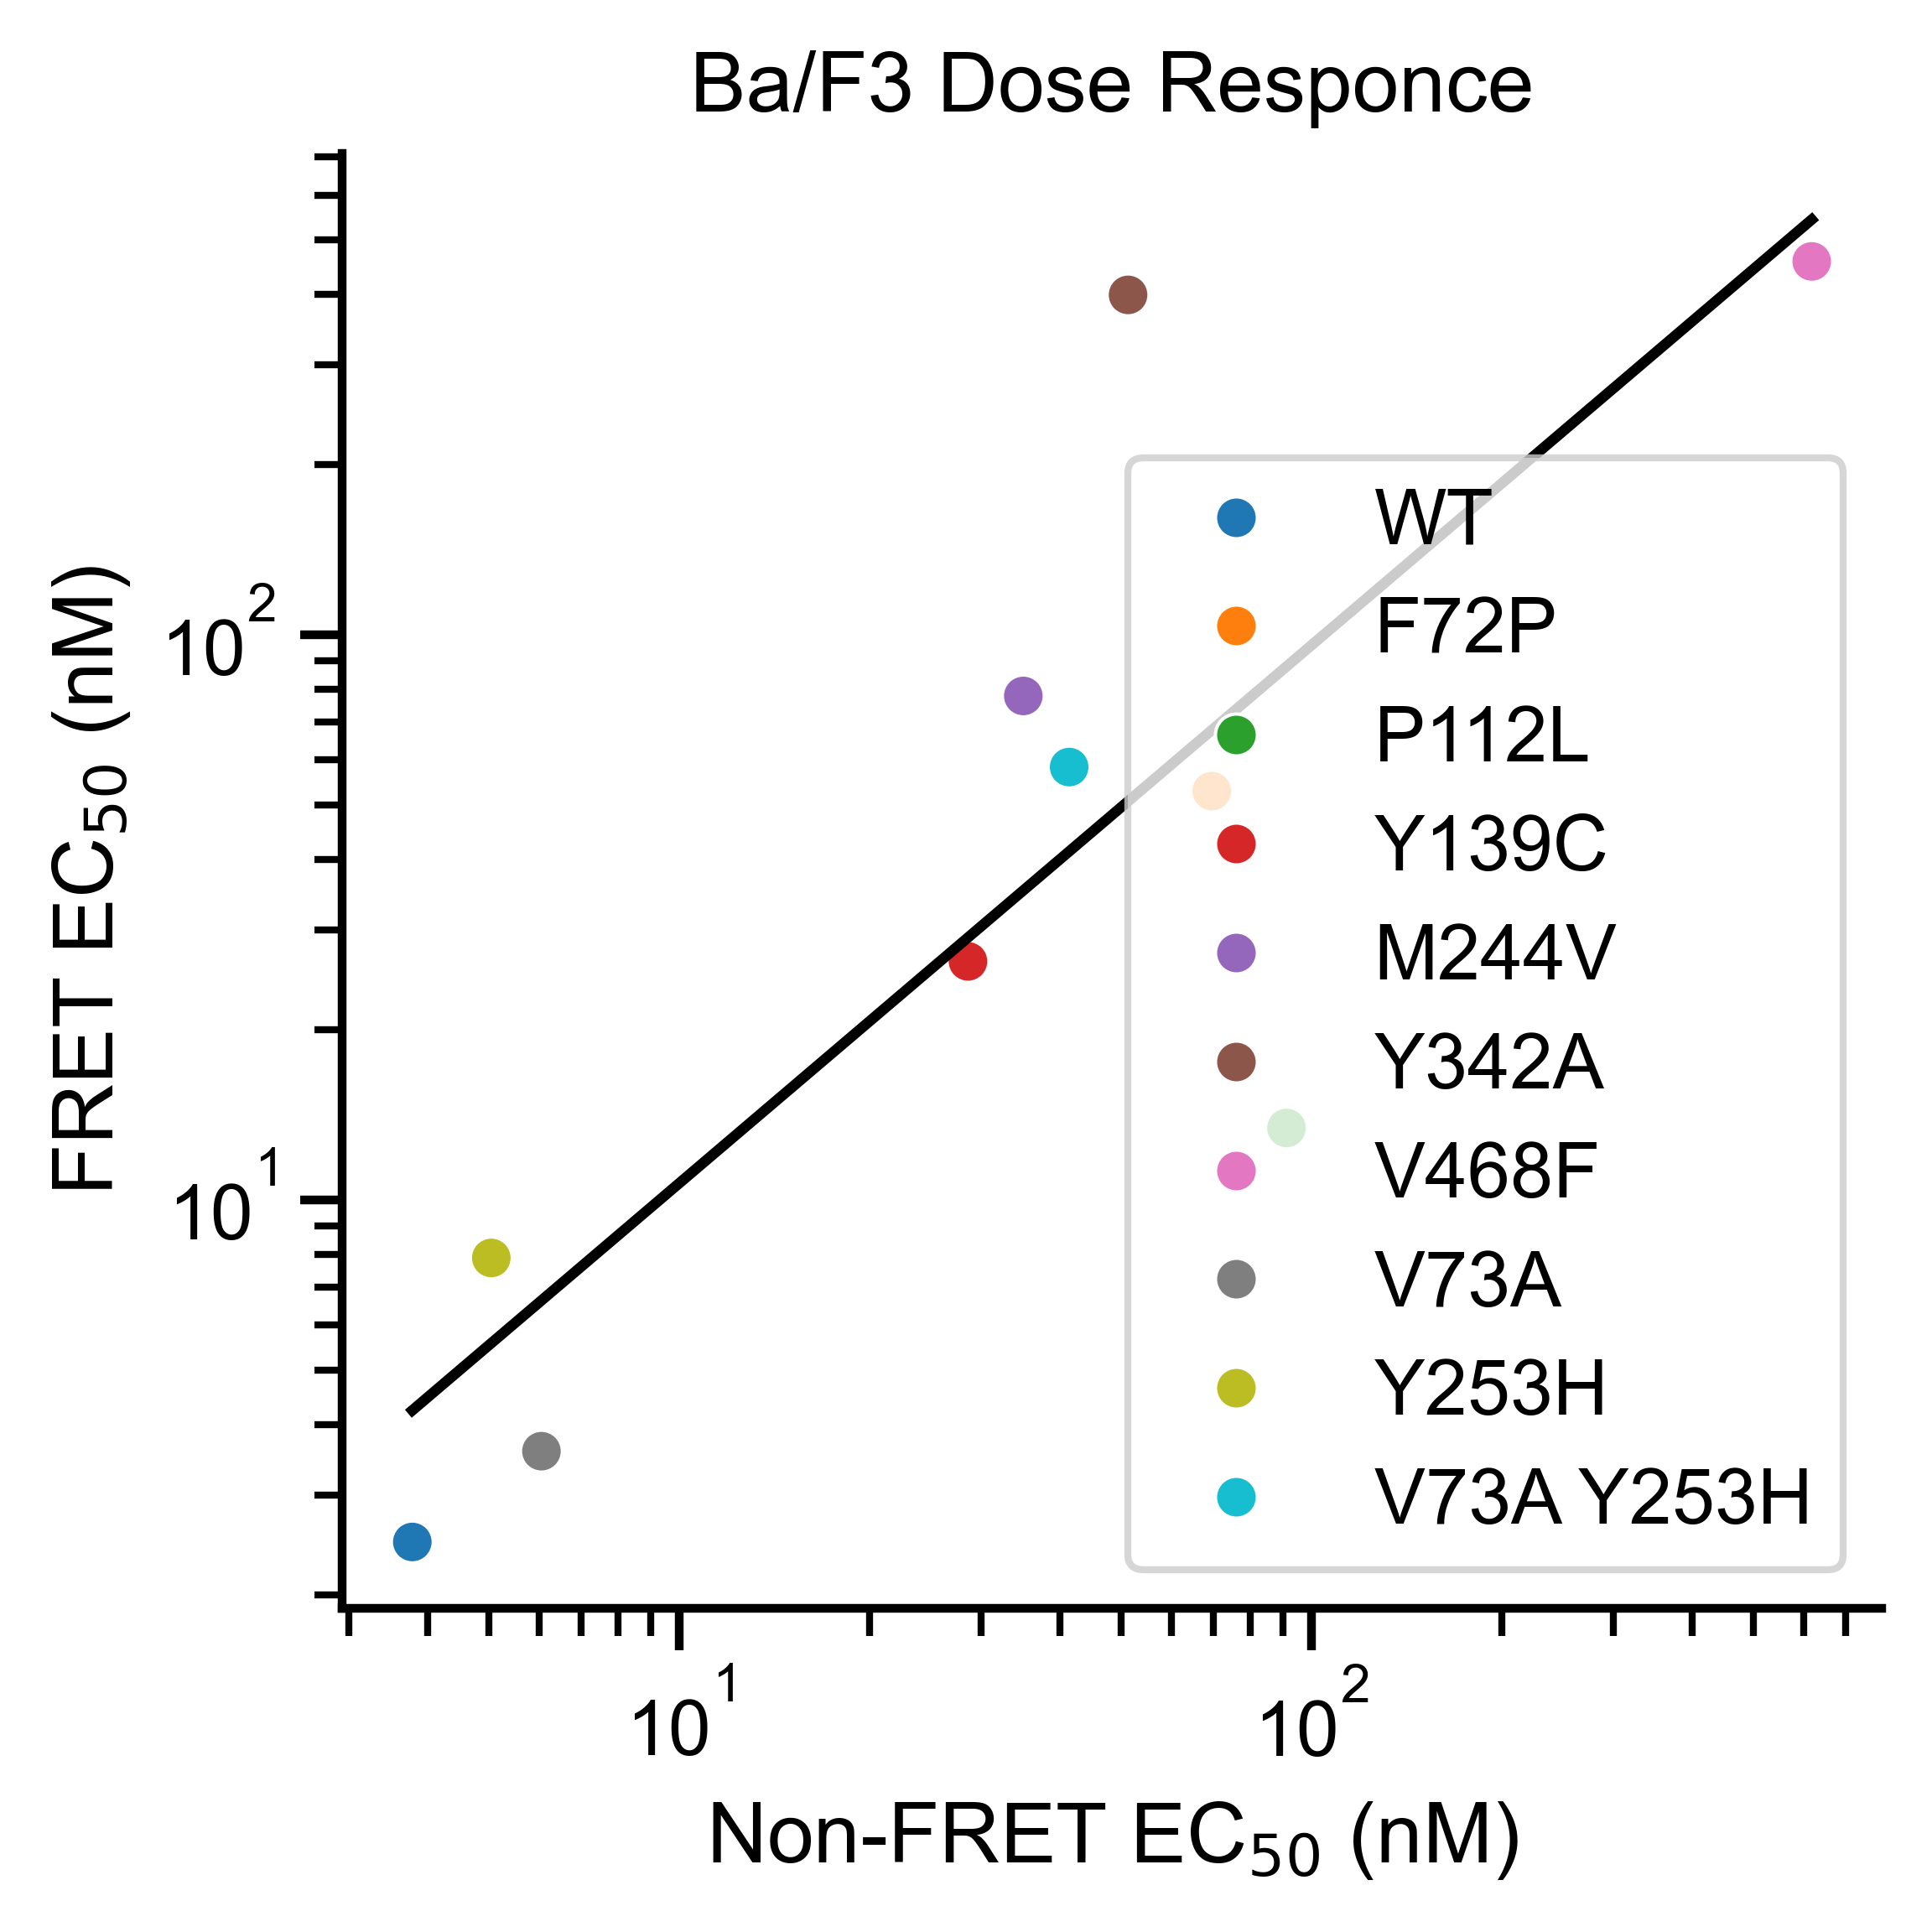

In [45]:
plt.rcParams['figure.figsize'] = 4,4
DR = sns.scatterplot(x='Non-FRET', y='FRET', hue='Cell', hue_order = order,  data=DR_DF)
sns.lineplot(x=X_space, y=Y_space, c='black')
DR.set(xscale='log', yscale='log', xlabel = 'Non-FRET EC$_{50}$ (nM)', ylabel = 'FRET EC$_{50}$ (nM)', title='Ba/F3 Dose Responce')
#DR.legend(frameon=False, bbox_to_anchor=(2, 1))
sns.despine()
DR
plt.tight_layout()
#DR.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/BaF3 FRET v NonFRET DR.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

In [8]:
os.chdir('/home/ivan/Desktop/Projects/HEK FRET 250115/20250115_FRET')

In [9]:
flow_data = []

for file in os.listdir():
    if file[-3:] == 'fcs':
        meta, data = fcsparser.parse(file, meta_data_only=False, reformat_meta=True)
        data = data.loc[(data['FSC-A'].between(3000000, 15000000)) & (data['SSC-A'] > 100000) & (data['FITC-A'].between(10000, 100000))]
        data['ScarSG_A'] = data['PerCP-A']/data['FITC-A']
        data = data.loc[data['ScarSG_A'].between(0.6,1)]
        flow_data.append([file.split(' ')[1], file.split(' ')[2], file.split(' ')[3],  file.split(' ')[4][:-4],  
                         data['ScarSG_A'].mean(), data['ScarSG_A'].count()])

flowDF = pd.DataFrame(flow_data, columns=['Cell', 'Drug', 'Conc', 'Rep','FRET', 'Count'])
flowDF = flowDF.sort_values(['Cell', 'Drug', 'Conc', 'Rep'])
flowDF.loc[flowDF['Cell']=='VAYH', 'Cell'] = 'V73A Y253H'

In [10]:
flowDF.to_csv('flowDF.csv')

In [13]:
flowDF.loc[flowDF['Count']<10000]

,Cell,Drug,Conc,Rep,FRET,Count
51,M244V,Asc,10,1,0.765167,8676
92,P112L,Asc,0,1,0.756692,5142
186,PC,Asc,0,1,0.829043,31
130,PC,Asc,0,2,0.806138,71
119,PC,Asc,0,3,0.774723,29
32,PC,Asc,0,4,0.758677,25
30,PC,Asc,0,5,0.856908,19
74,PC,Asc,0,6,0.797711,41
139,PC,Asc,1000,1,0.845626,31
56,PC,Asc,1000,2,0.812905,15


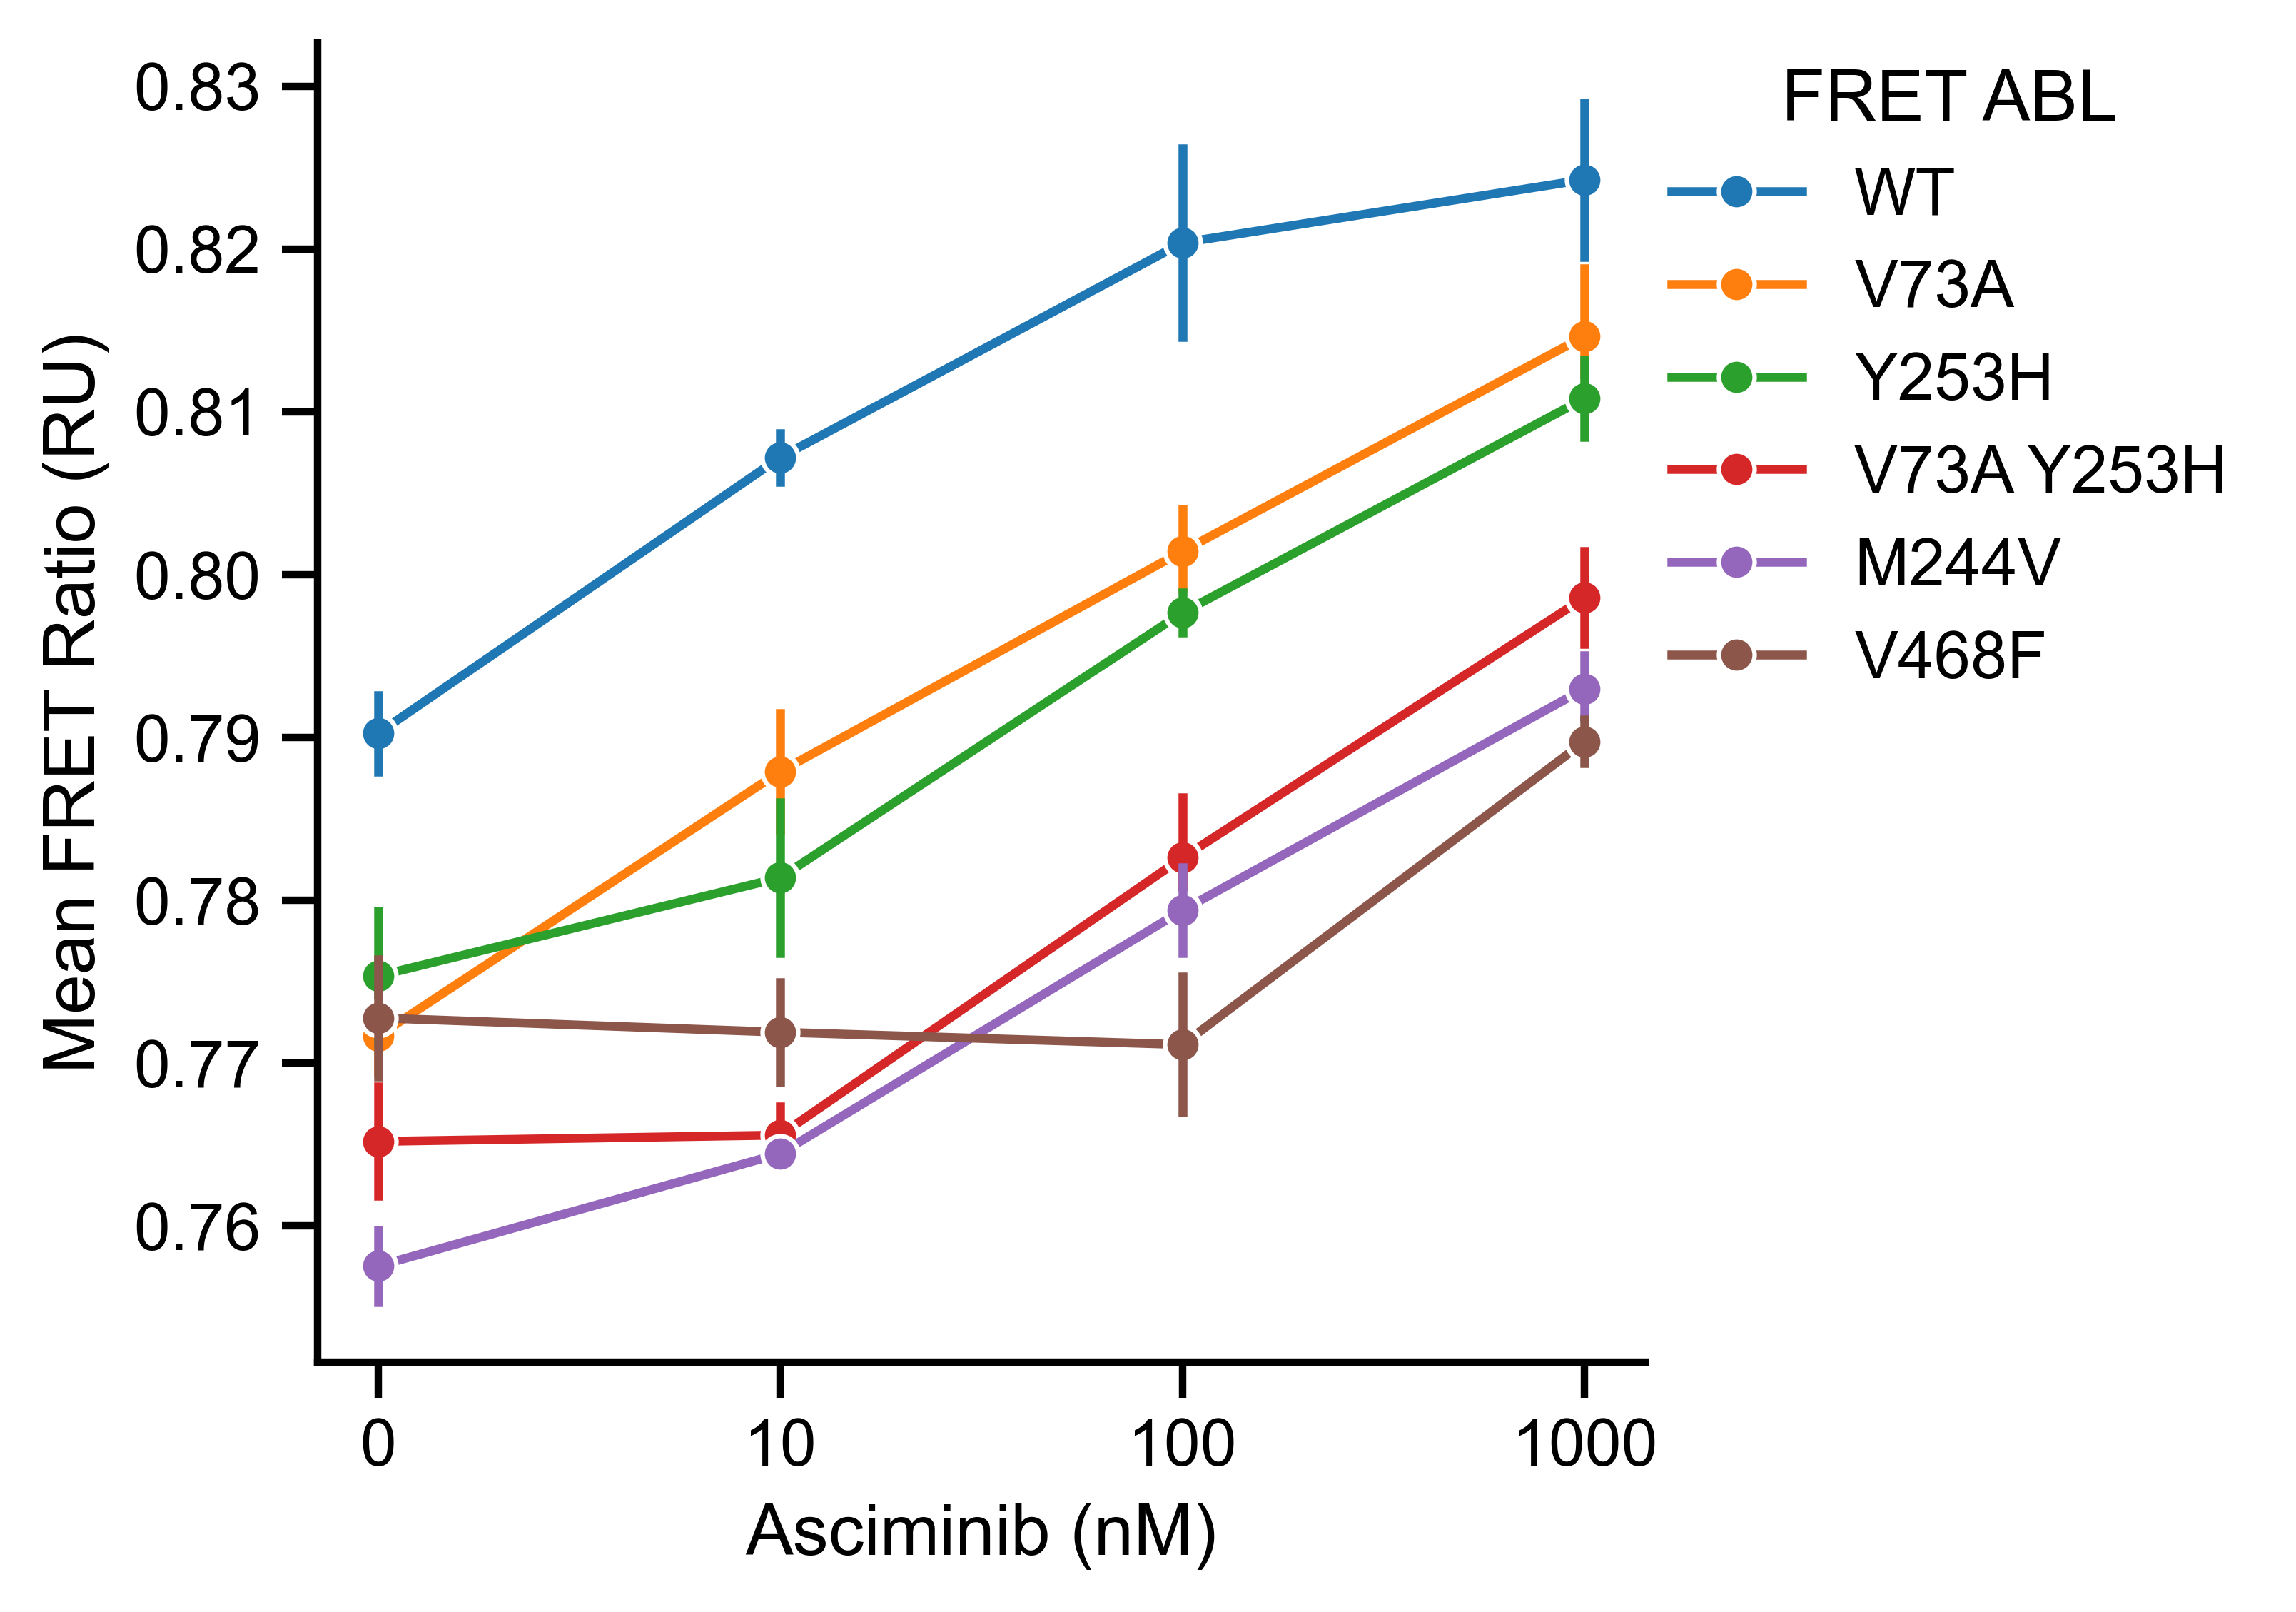

In [55]:
plt.rcParams['figure.figsize'] = 4,4
epi_only = ['WT', 'V73A', 'Y253H', 'V73A Y253H', 'M244V', 'V468F']
flowDF_AscEpi = flowDF.loc[(flowDF['Drug']=='Asc') & (flowDF['Cell'].isin(epi_only)) ]
fret_flow = sns.lineplot(x='Conc', y='FRET', hue='Cell', hue_order = epi_only, marker='o', errorbar = 'sd', err_style='bars',data=flowDF_AscEpi)
fret_flow.set(ylabel='Mean FRET Ratio (RU)', xlabel='Asciminib (nM)')
sns.despine()
fret_flow.legend(bbox_to_anchor=(1,1), borderaxespad=0, frameon=False, title='FRET ABL')

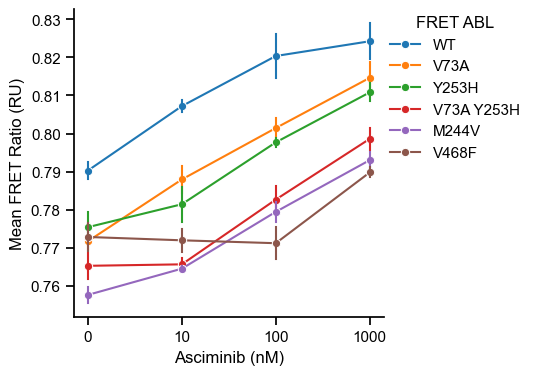

In [12]:
plt.rcParams['figure.figsize'] = 4,4
epi_only = ['WT', 'V73A', 'Y253H', 'V73A Y253H', 'M244V', 'V468F']
flowDF_AscEpi = flowDF.loc[(flowDF['Drug']=='Asc') & (flowDF['Cell'].isin(epi_only)) ]
fret_flow = sns.lineplot(x='Conc', y='FRET', hue='Cell', hue_order = epi_only, marker='o', errorbar = 'sd', err_style='bars',data=flowDF_AscEpi)
fret_flow.set(ylabel='Mean FRET Ratio (RU)', xlabel='Asciminib (nM)')
sns.despine()
fret_flow.legend(bbox_to_anchor=(1,1), borderaxespad=0, frameon=False, title='FRET ABL')
fret_flow.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/FRET Sensor/FRET3 DR Epi 250130.pdf', dpi=1200, transparent=True ,bbox_inches='tight')

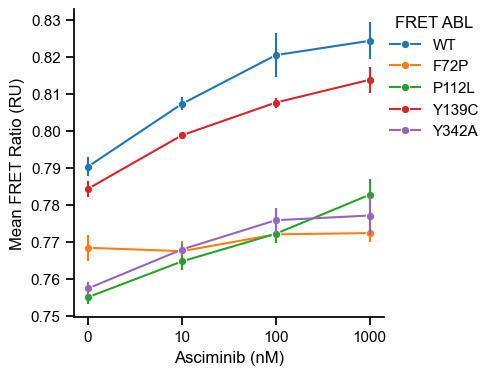

In [231]:
Others = ['WT', 'F72P', 'P112L', 'Y139C', 'Y342A']
flowDF_others = flowDF.loc[(flowDF['Drug']=='Asc') & (flowDF['Cell'].isin(Others))]
fret_flow = sns.lineplot(x='Conc', y='FRET', hue='Cell', hue_order = Others, marker='o', errorbar = 'sd', err_style='bars',data=flowDF_others)
fret_flow.set(ylabel='Mean FRET Ratio (RU)', xlabel='Asciminib (nM)')
sns.despine()
fret_flow.legend(bbox_to_anchor=(1,1), borderaxespad=0, frameon=False, title='FRET ABL')
fret_flow.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/FRET Sensor/FRET3 DR Other 250130.pdf', dpi=1200, transparent=True ,bbox_inches='tight')

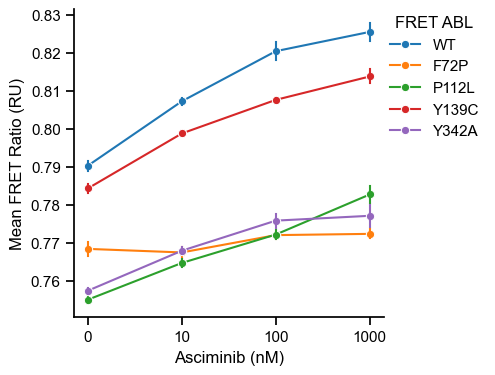

In [48]:
Others = ['WT', 'F72P', 'P112L', 'Y139C', 'Y342A']
flowDF_others = flowDF.loc[(flowDF['Drug']=='Asc') & (flowDF['Cell'].isin(Others))]
fret_flow = sns.lineplot(x='Conc', y='FRET', hue='Cell', hue_order = Others, marker='o', errorbar = 'se', err_style='bars',data=flowDF_others)
fret_flow.set(ylabel='Mean FRET Ratio (RU)', xlabel='Asciminib (nM)')
sns.despine()
fret_flow.legend(bbox_to_anchor=(1,1), borderaxespad=0, frameon=False, title='FRET ABL')

In [56]:
BaF3_EC50s = [['WT'	, 3.78],
['F72P'	, 69.53],
['G76R'	, 6.31],
['P112L'	, 91.29],
['G130E'	, 53.95],
['Y139C'	, 28.61],
['M244T'	, 15.25],
['M244V'	, 35],
['T277A'	, 16.55],
['E292V'	, 86.34],
['F311L'	, 32.89],
['T315I'	, 47.35],
['F317L'	, 29.97],
['D325G'	, 11.2],
['Y139H'	, 45.55],
['M351T'	, 13.47],
['V468F'	, 618.42],
['I502L'	, 138.9],
['E505G'	, 119.74],
['H375A'	, 1.78],
['Y342A'	, 51.26],
['Y253H'	, 5.04],
['V73A'	, 6.05],
['V73A Y253H', 41.36]]

In [57]:
EC50_DF = pd.DataFrame(BaF3_EC50s, columns=['Cell', 'EC50'])
flowDF_AscMeans = flowDF.loc[flowDF['Drug']=='Asc', ['Cell', 'Conc', 'FRET']].groupby(['Cell', 'Conc']).mean().reset_index()

In [58]:
flow_EC50_DF = pd.merge(flowDF_AscMeans, DR_DF, on='Cell')

In [59]:
flow_EC50_100 = flow_EC50_DF.loc[flow_EC50_DF['Conc']=='100']

In [60]:
flow_EC50_100[['FRET_x', 'LogNF']].corr()

,FRET_x,LogNF
FRET_x,1.000000,-0.815725
LogNF,-0.815725,1.000000


In [61]:
# Create and fit the linear regression model in logspace
model = LinearRegression()
model.fit(flow_EC50_100['LogNF'].values.reshape(-1, 1), flow_EC50_100['FRET_x'].values)

def log10_space_function(x_log10):
    return( (model.coef_ * x_log10) + model.intercept_)

X_space = 10**np.linspace(DR_DF['LogNF'].min(), DR_DF['LogNF'].max(), 200)
Y_space = log10_space_function(np.linspace(DR_DF['LogNF'].min(), DR_DF['LogNF'].max(), 200))

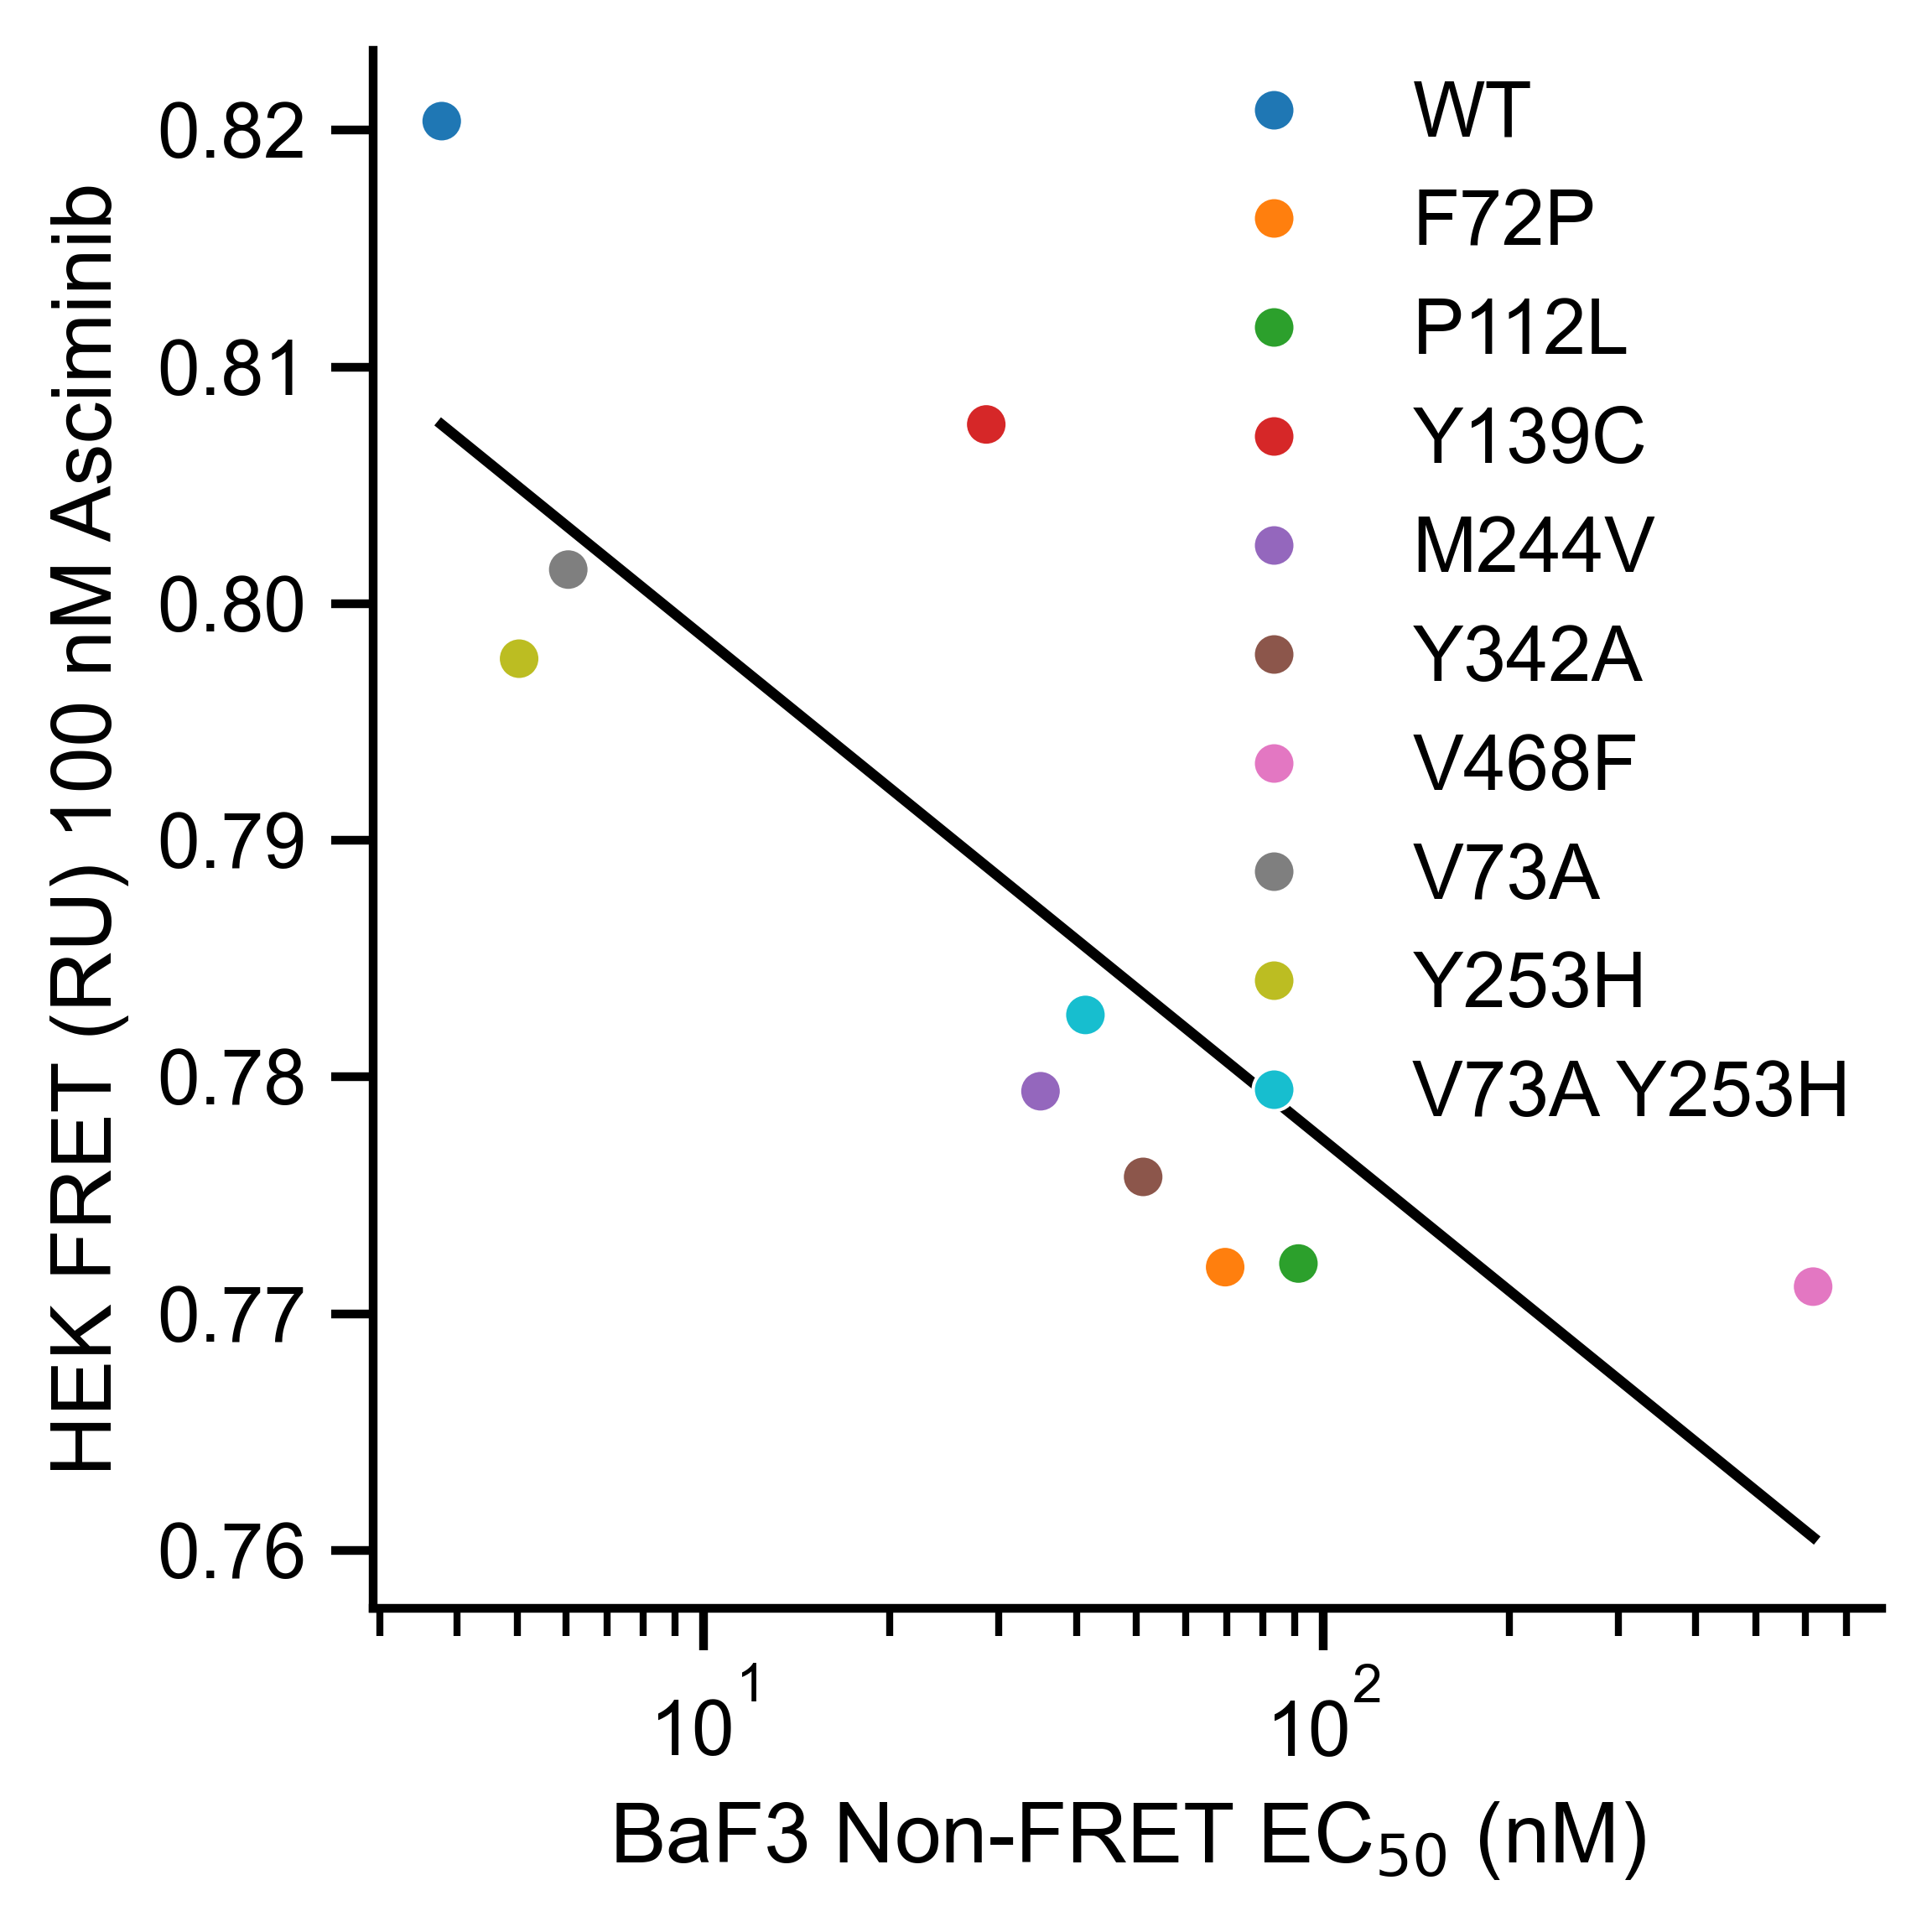

In [62]:
compare = sns.scatterplot(x='Non-FRET', y='FRET_x', hue='Cell', hue_order = order, data=flow_EC50_DF.loc[flow_EC50_DF['Conc']=='100'])
compare.set(xscale='log', xlabel = 'BaF3 Non-FRET EC$_{50}$ (nM)', ylabel = 'HEK FRET (RU) 100 nM Asciminib')
sns.lineplot(x=X_space, y=Y_space, c='black', zorder=0)
compare.legend(borderaxespad=0, frameon=False)
sns.despine()
plt.tight_layout()
compare.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/HEK FRET v BaF3 NonFRET EC50.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

In [63]:
sns.set_context('talk')
mpl.rcParams['figure.figsize'] =6,5

NameError: name 'mpl' is not defined

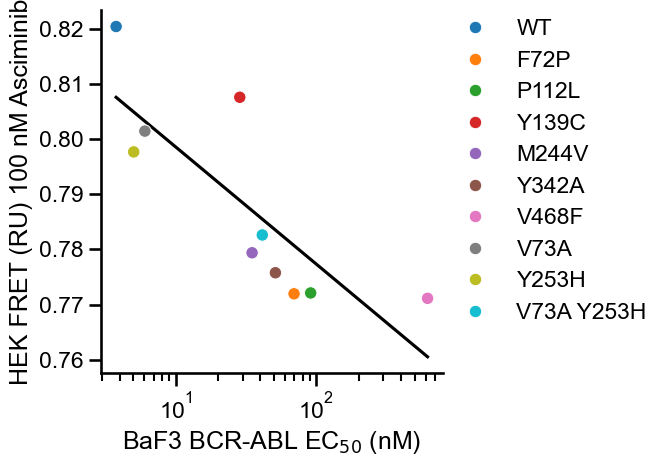

In [28]:
plt.rcParams['figure.figsize'] =7,5
compare = sns.scatterplot(x='Non-FRET', y='FRET_x', hue='Cell', hue_order = order, data=flow_EC50_DF.loc[flow_EC50_DF['Conc']=='100'])
compare.set(xscale='log', xlabel = 'BaF3 BCR-ABL EC$_{50}$ (nM)', ylabel = 'HEK FRET (RU) 100 nM Asciminib')
sns.lineplot(x=X_space, y=Y_space, c='black', zorder=0)
compare.legend(borderaxespad=0, frameon=False, bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
compare.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/HEK FRET v BaF3 NonFRET EC50_talk.png" , dpi=1200,  transparent=True, bbox_inches='tight')

In [64]:
flow_EC50_DF.loc[flow_EC50_DF['Conc']=='100']

,Cell,Conc,FRET_x,FRET_y,Non-FRET,LogF,LogNF
2,F72P,100,0.771966,52.88,69.53,1.723291,1.842172
6,M244V,100,0.779399,77.92,35.00,1.891649,1.544068
10,P112L,100,0.772119,13.40,91.29,1.127105,1.960423
14,V468F,100,0.771143,457.77,618.42,2.660647,2.791284
18,V73A,100,0.801438,3.59,6.05,0.555094,0.781755
22,V73A Y253H,100,0.782622,58.32,41.36,1.765818,1.616581
26,WT,100,0.820385,2.48,3.78,0.394452,0.577492
30,Y139C,100,0.807570,26.42,28.61,1.421933,1.456518
34,Y253H,100,0.797674,7.89,5.04,0.897077,0.702431
38,Y342A,100,0.775780,399.43,51.26,2.601441,1.709779


## Basline Adjusted FRET Values

In [30]:
flowDF_0 = flowDF.loc[flowDF['Conc']=='0', ['Cell', 'Rep', 'FRET']]
flowDF_0.columns = ['Cell', 'Rep', 'FRET_0']
flowDF2 = pd.merge(flowDF,flowDF_0, on=['Cell', 'Rep'])
flowDF2['FRET_adj'] = flowDF2['FRET'] - flowDF2['FRET_0'] 

In [31]:
flowDF_AscEpi

,Cell,Drug,Conc,Rep,FRET,Count,FRET_0,FRET_adj
36,M244V,Asc,0,1,0.756390,17066,0.756390,0.0
37,M244V,Asc,0,2,0.756170,13929,0.756170,0.0
38,M244V,Asc,0,3,0.760081,16661,0.760081,0.0
39,M244V,Asc,10,1,0.765167,8676,0.756390,0.0
40,M244V,Asc,10,2,0.764093,23166,0.756170,0.0
...,...,...,...,...,...,...,...,...
186,Y253H,Asc,100,2,0.796891,42173,0.774523,0.0
187,Y253H,Asc,100,2,0.799086,43990,0.774523,0.0
188,Y253H,Asc,1000,1,0.812924,43997,0.779725,0.0
189,Y253H,Asc,1000,2,0.811310,42834,0.774523,0.0


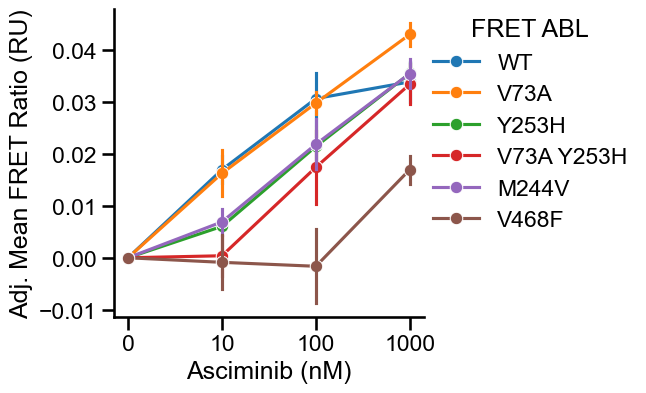

In [63]:
plt.rcParams['figure.figsize'] = 4,4
epi_only = ['WT', 'V73A', 'Y253H', 'V73A Y253H', 'M244V', 'V468F']
flowDF_AscEpi = flowDF2.loc[(flowDF2['Drug']=='Asc') & (flowDF2['Cell'].isin(epi_only)) ]
fret_flow = sns.lineplot(x='Conc', y='FRET_adj', hue='Cell', hue_order = epi_only, marker='o', errorbar = 'sd', err_style='bars',data=flowDF_AscEpi)
fret_flow.set(ylabel='Adj. Mean FRET Ratio (RU)', xlabel='Asciminib (nM)')
sns.despine()
fret_flow.legend(bbox_to_anchor=(1,1), borderaxespad=0, frameon=False, title='FRET ABL')
fret_flow.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/FRET Sensor/Adjusted FRET3 DR Epi 260111.pdf', dpi=1200, transparent=True ,bbox_inches='tight')

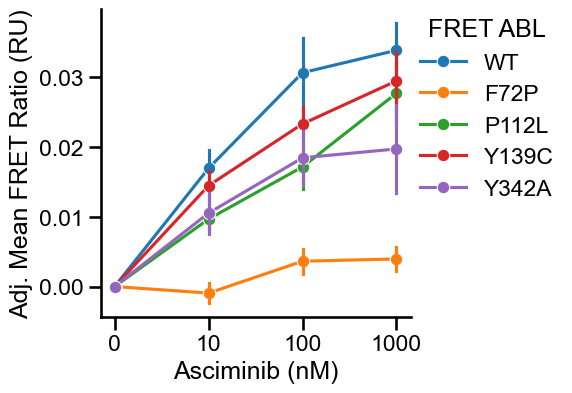

In [64]:
plt.rcParams['figure.figsize'] = 4,4
Others = ['WT', 'F72P', 'P112L', 'Y139C', 'Y342A']
flowDF_others = flowDF2.loc[(flowDF2['Drug']=='Asc') & (flowDF2['Cell'].isin(Others))]
fret_flow = sns.lineplot(x='Conc', y='FRET_adj', hue='Cell', hue_order = Others, marker='o', errorbar = 'sd', err_style='bars',data=flowDF_others)
fret_flow.set(ylabel='Adj. Mean FRET Ratio (RU)', xlabel='Asciminib (nM)')
sns.despine()
fret_flow.legend(bbox_to_anchor=(1,1), borderaxespad=0, frameon=False, title='FRET ABL')
fret_flow.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/FRET Sensor/Adjusted FRET3 DR Other 260111.pdf', dpi=1200, transparent=True ,bbox_inches='tight')

In [45]:
flow100_adj_FRET = flowDF2.loc[(flowDF2['Conc']=='100') & (flowDF2['Drug']=='Asc'), ['Cell', 'FRET_adj']].groupby(['Cell']).mean().reset_index()
EC50_flow100_adj_FRET = pd.merge(flow_EC50_100, flow100_adj_FRET, on='Cell')

In [46]:
EC50_flow100_adj_FRET

,Cell,Conc,FRET_x,FRET_y,Non-FRET,LogF,LogNF,FRET_adj
0,F72P,100,0.771966,52.88,69.53,1.723291,1.842172,0.003625
1,M244V,100,0.779399,77.92,35.00,1.891649,1.544068,0.021851
2,P112L,100,0.772119,13.40,91.29,1.127105,1.960423,0.017145
3,V468F,100,0.771143,457.77,618.42,2.660647,2.791284,-0.001638
4,V73A,100,0.801438,3.59,6.05,0.555094,0.781755,0.029770
5,V73A Y253H,100,0.782622,58.32,41.36,1.765818,1.616581,0.017424
6,WT,100,0.820385,2.48,3.78,0.394452,0.577492,0.030636
7,Y139C,100,0.807570,26.42,28.61,1.421933,1.456518,0.023303
8,Y253H,100,0.797674,7.89,5.04,0.897077,0.702431,0.021417
9,Y342A,100,0.775780,399.43,51.26,2.601441,1.709779,0.018440


In [53]:
sns.set_context('talk')

In [55]:
# Create and fit the linear regression model in logspace
model = LinearRegression()
model.fit(EC50_flow100_adj_FRET['LogNF'].values.reshape(-1, 1), EC50_flow100_adj_FRET['FRET_adj'].values)

def log10_space_function(x_log10):
    return( (model.coef_ * x_log10) + model.intercept_)

X_space = 10**np.linspace(DR_DF['LogNF'].min(), DR_DF['LogNF'].max(), 200)
Y_space = log10_space_function(np.linspace(DR_DF['LogNF'].min(), DR_DF['LogNF'].max(), 200))

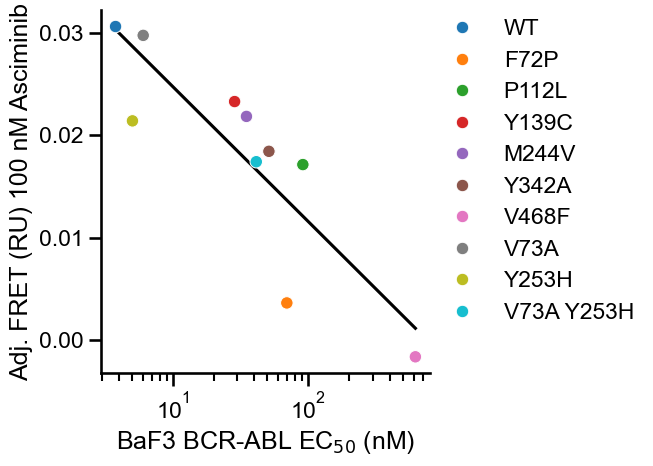

In [58]:
plt.rcParams['figure.figsize'] =7,5
compare = sns.scatterplot(x='Non-FRET', y='FRET_adj', hue='Cell', hue_order = order, data=EC50_flow100_adj_FRET)
compare.set(xscale='log', xlabel = 'BaF3 BCR-ABL EC$_{50}$ (nM)', ylabel = 'Adj. FRET (RU) 100 nM Asciminib')
sns.lineplot(x=X_space, y=Y_space, c='black', zorder=0)
compare.legend(borderaxespad=0, frameon=False, bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
compare.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/Adj FRET v BaF3 NonFRET EC50_talk.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

In [51]:
EC50_flow100_adj_FRET[['FRET_adj', 'LogNF']].corr()

,FRET_adj,LogNF
FRET_adj,1.000000,-0.863793
LogNF,-0.863793,1.000000


## Quality Control

In [15]:
flow_data = []

for file in os.listdir():
    if file[-3:] == 'fcs':
        if file.split(' ')[1] in ['ScarSG', 'WT', 'PC']:
            if 'Asc' in file:
                meta, data = fcsparser.parse(file, meta_data_only=False, reformat_meta=True)
                data = data.loc[(data['FSC-A'].between(3000000, 15000000)) & (data['SSC-A'] > 100000) & (data['FITC-A'].between(10000, 100000))]
                data['ScarSG_A'] = data['PerCP-A']/data['FITC-A']
                if file.split(' ')[1] == 'ScarSG':   
                    data = data.loc[data['ScarSG_A'].between(0.2,1)]
                if file.split(' ')[1] == 'WT':   
                    data = data.loc[data['ScarSG_A'].between(0.6,1)]
                if file.split(' ')[1] == 'PC':   
                    data = data.loc[data['ScarSG_A'].between(2,4)]
                flow_data.append([file.split(' ')[1], file.split(' ')[2], file.split(' ')[3],  file.split(' ')[4][:-4],  
                                 data['ScarSG_A'].mean(), data['ScarSG_A'].count()])

flowDF = pd.DataFrame(flow_data, columns=['Cell', 'Drug', 'Conc', 'Rep','FRET', 'Count'])
#flowDF = flowDF.loc[flowDF['Cell'].isin(intrest)].sort_values(['Cell', 'Conc'])
flowDF = flowDF.sort_values(['Cell', 'Drug', 'Conc', 'Rep'])
flowDF.loc[flowDF['Cell']=='VAYH', 'Cell'] = 'V73A Y253H'

In [16]:
flowDF = flowDF.loc[flowDF['Conc'].isin(['0', '1000'])] 

In [17]:
flowDF['Treatment'] = None
flowDF.loc[flowDF['Conc']=='0', 'Treatment'] = 'DMSO'
flowDF.loc[flowDF['Conc']=='1000', 'Treatment'] = 'Asciminib'

/tmp/ipykernel_356876/3585310745.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  qc.set_xticklabels(['ABL FRET', 'ABL mSarlet3 \n + \n ABL mStayGold', 'Short Fusion'])


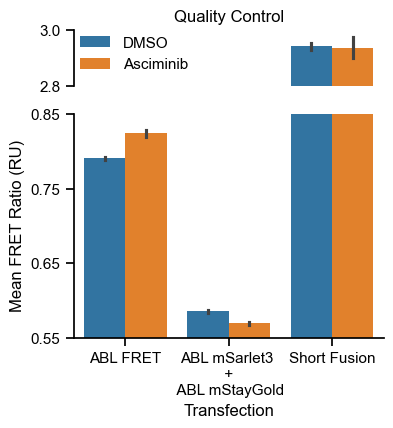

In [18]:
plt.rcParams['figure.figsize'] = 4,4

f, (ax, ax2) = plt.subplots(2,1, sharex=True, gridspec_kw={'hspace': 0.2, 'height_ratios': [1,4]})

qc=sns.barplot(x='Cell', y='FRET', hue='Treatment', errorbar='sd', data=flowDF, order=['WT', 'ScarSG', 'PC'], ax=ax)
qc2=sns.barplot(x='Cell', y='FRET', hue='Treatment', errorbar='sd', legend=False, data=flowDF, order=['WT', 'ScarSG', 'PC'], ax=ax2)


ax2.set_ylim(0.55, 0.85)
ax.set_ylim(2.9, 3)
ax2.spines['bottom'].set_visible(False)

qc.set(title='Quality Control', ylabel=None )
qc.set_yticks([2.8, 3])
qc.set_yticklabels(['2.8', '3.0'])
qc2.set(xlabel='Transfection', ylabel='Mean FRET Ratio (RU)')
qc2.set_yticks([0.55, 0.65, 0.75, 0.85])
qc2.set_yticklabels(['0.55','0.65', '0.75', '0.85'])
qc.set_xticklabels(['ABL FRET', 'ABL mSarlet3 \n + \n ABL mStayGold', 'Short Fusion'])
qc.legend(borderaxespad=0, frameon=False)
sns.despine()
ax.spines[['bottom']].set_visible(False)
ax.tick_params(bottom=False)
f.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/HEK FRET Quality Control PC.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

/tmp/ipykernel_356876/255316180.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels)
/tmp/ipykernel_356876/255316180.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


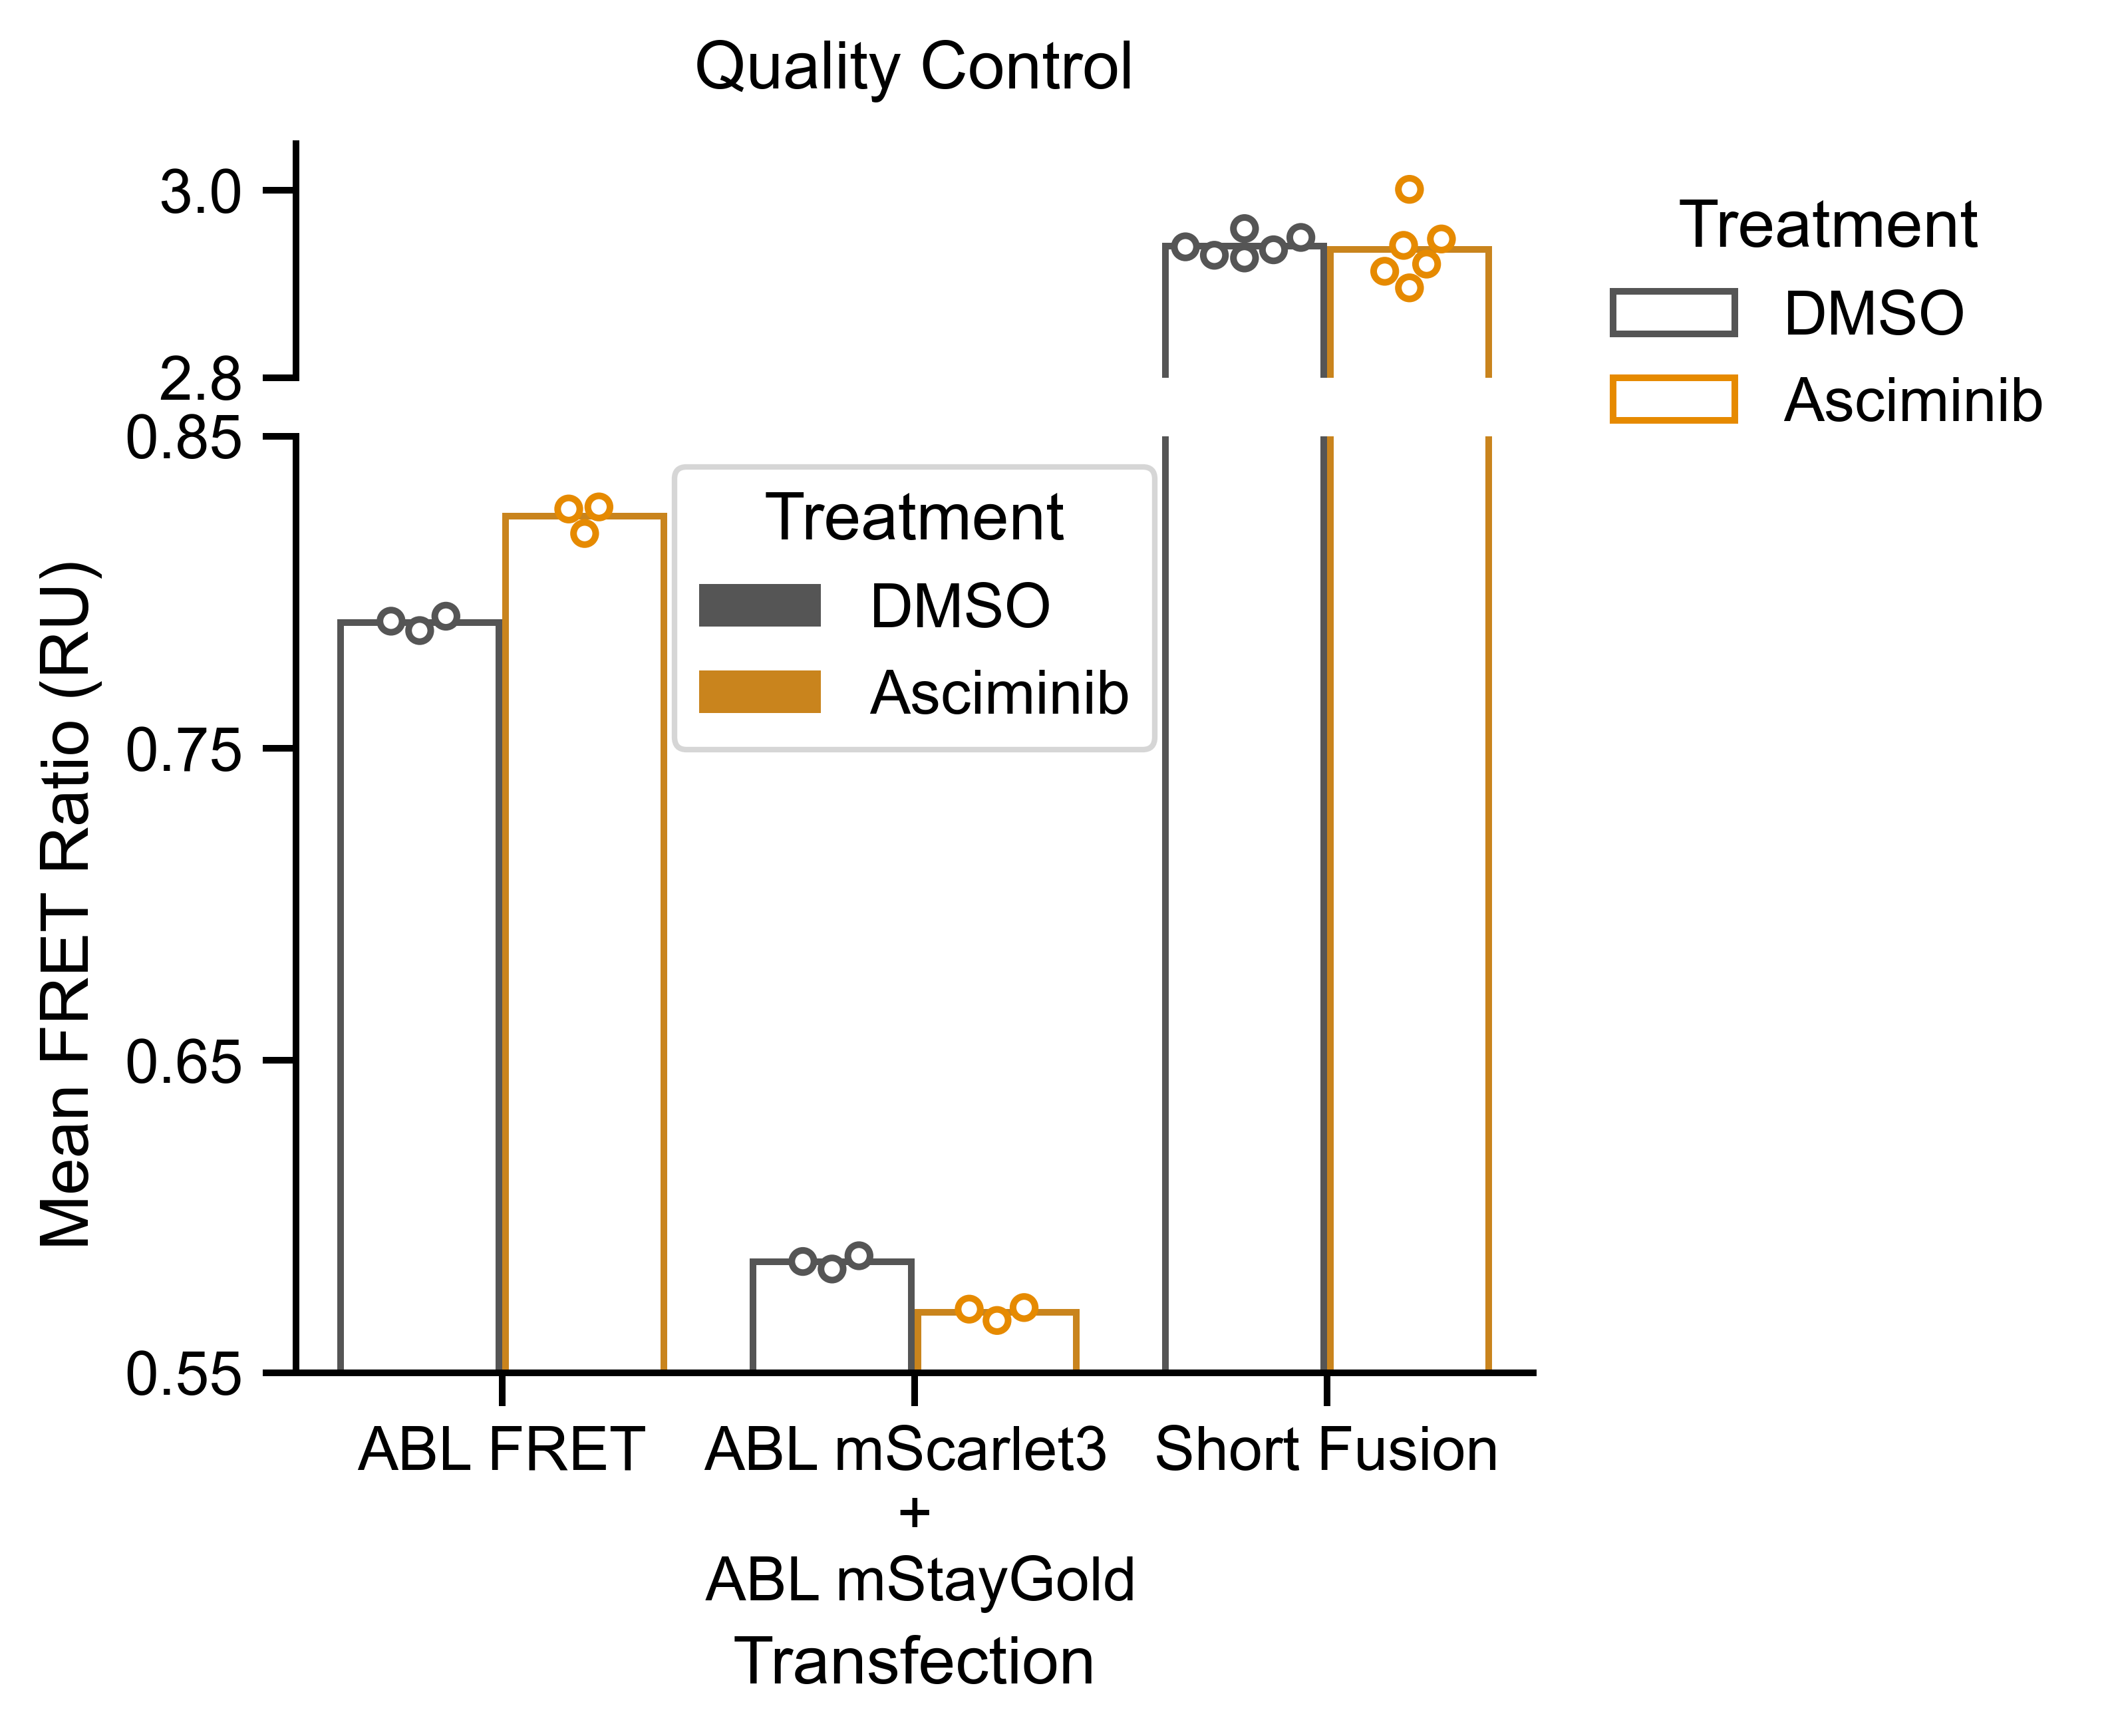

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.collections 
from matplotlib.patches import Patch

# --- 1. PUBLICATION PARAMETERS ---
LW = 1.2
plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.linewidth': LW,
    'xtick.major.width': LW,
    'ytick.major.width': LW,
    'pdf.fonttype': 42
})

# --- 2. DATA & SETUP ---
# Assumptions based on your PDF:
order = ['WT', 'ScarSG', 'PC']
hue_order = ['DMSO', 'Asciminib'] 
my_palette = ["#555555", "#E68A00"] 

# Initialize Figure with Broken Axis
fig, (ax, ax2) = plt.subplots(2, 1, sharex=True, figsize=(4, 4),
                               gridspec_kw={'hspace': 0.1, 'height_ratios': [1, 4]})

# --- 3. PLOTTING FUNCTION ---
def plot_subplot(target_ax, show_legend=False):
    # A. The Bars (No error bars)
    sns.barplot(
        data=flowDF,
        x='Cell',
        y='FRET',
        hue='Treatment',
        order=order,
        hue_order=hue_order,
        palette=my_palette,
        gap=0.04,
        dodge=True,
        linewidth=LW,
        errorbar=None,    
        ax=target_ax,
        zorder=2
    )

    # B. The Swarm (Dots)
    sns.swarmplot(
        data=flowDF,
        x='Cell',
        y='FRET',
        hue='Treatment',
        order=order,
        hue_order=hue_order,
        palette=my_palette,
        dodge=True,
        size=4,
        ax=target_ax,
        zorder=3,
        legend=False 
    )

    # C. Style Processing: Make everything White Fill + Colored Border
    
    # Process Bars
    for bar in target_ax.patches:
        clr = bar.get_facecolor()
        bar.set_edgecolor(clr)
        bar.set_facecolor("white")
        bar.set_zorder(2)
        
    # Process Swarm Points
    for collection in target_ax.collections:
        if isinstance(collection, matplotlib.collections.PathCollection):
            original_color = collection.get_facecolor()
            if len(original_color) > 0:
                collection.set_edgecolor(original_color)
                collection.set_facecolor("white")
                collection.set_linewidth(LW)

# --- 4. EXECUTE PLOTS ---
plot_subplot(ax, show_legend=False)
plot_subplot(ax2, show_legend=False)

# --- 5. BROKEN AXIS STYLING ---
# Set limits 
ax.set_ylim(2.8, 3.05)   # Top segment
ax2.set_ylim(0.55, 0.85) # Bottom segment

# Hide the spines between the plots to create the "break" effect
ax.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(labelbottom=False, bottom=False)

# (Diagonal break lines removed here)

# --- 6. LABELS & TICKS ---
ax.set_title('Quality Control', pad=10)
ax.set_xlabel('')
ax.set_ylabel('')

ax2.set_xlabel('Transfection')
ax2.set_ylabel('Mean FRET Ratio (RU)')

# Custom Y-Ticks
ax.set_yticks([2.8, 3.0])
ax2.set_yticks([0.55, 0.65, 0.75, 0.85])

# X-Labels
labels = ['ABL FRET', 'ABL mScarlet3 \n + \n ABL mStayGold', 'Short Fusion']
ax2.set_xticklabels(labels)

# --- 7. CUSTOM LEGEND ---
legend_elements = [
    Patch(facecolor='white', edgecolor=my_palette[0], linewidth=LW, label=hue_order[0]),
    Patch(facecolor='white', edgecolor=my_palette[1], linewidth=LW, label=hue_order[1])
]

ax.legend(handles=legend_elements, 
          title='Treatment', 
          frameon=False, 
          loc='upper left', 
          bbox_to_anchor=(1.02, 1))

# --- 8. FINAL CLEANUP ---
sns.despine(ax=ax, bottom=True)
sns.despine(ax=ax2, top=True)

plt.tight_layout()
plt.savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/HEK FRET Quality Control PC Swarm.pdf", transparent=True, dpi=1200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_7431/2033863224.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
/tmp/ipykernel_7431/2033863224.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


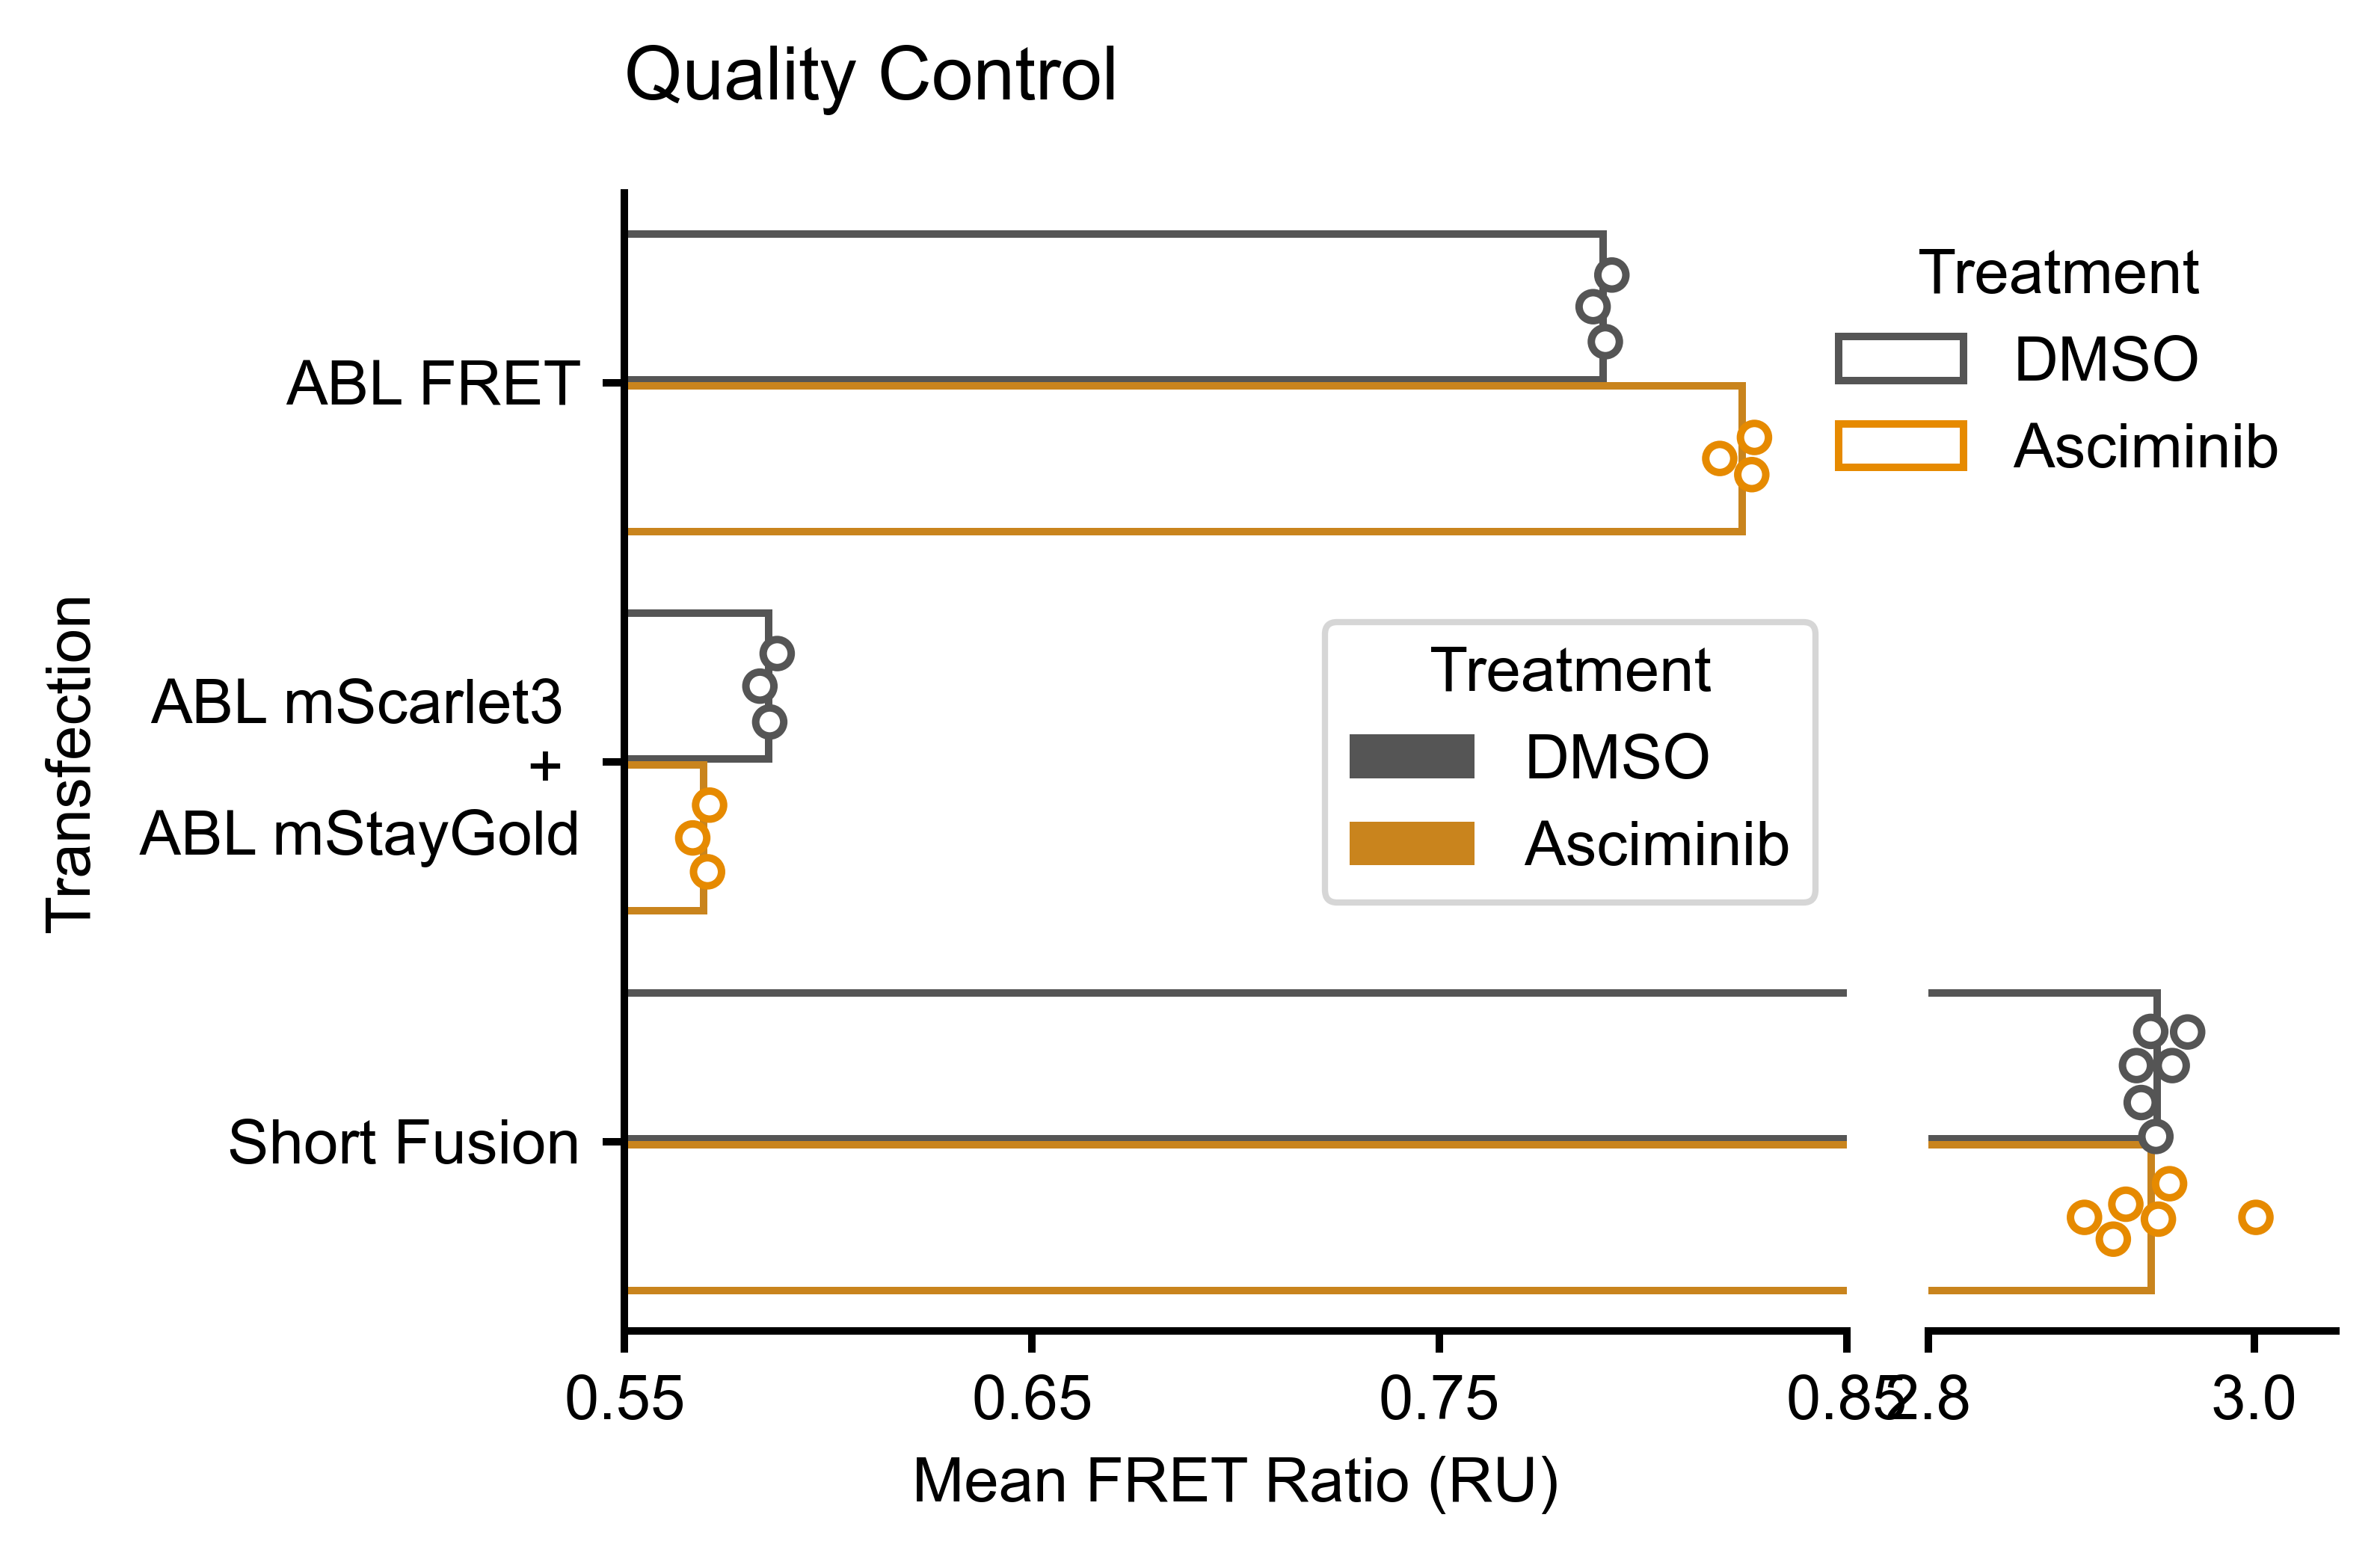

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.collections 
from matplotlib.patches import Patch

# --- 1. PUBLICATION PARAMETERS ---
LW = 1.2
# Conversion: mm to inches
width_inch = 250 / 25.4 /2
height_inch = 167.4 / 25.4/2

plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.linewidth': LW,
    'xtick.major.width': LW,
    'ytick.major.width': LW,
    'pdf.fonttype': 42
})

# --- 2. DATA & SETUP ---
# [cite_start]Data labels and order derived from previous inputs [cite: 1, 11]
order = ['WT', 'ScarSG', 'PC']
hue_order = ['DMSO', 'Asciminib'] # Treatments identified in source [cite: 3, 4]
my_palette = ["#555555", "#E68A00"] 

# Initialize Figure with specific mm dimensions
fig, (ax, ax2) = plt.subplots(1, 2, sharey=True, figsize=(width_inch, height_inch),
                               gridspec_kw={'wspace': 0.1, 'width_ratios': [3, 1]})

# --- 3. PLOTTING FUNCTION ---
def plot_subplot(target_ax):
    # Bars (Horizontal: x=FRET, y=Cell)
    sns.barplot(
        data=flowDF,
        x='FRET',          
        y='Cell',          
        hue='Treatment',
        order=order,
        hue_order=hue_order,
        palette=my_palette,
        gap=0.04,
        dodge=True,
        linewidth=LW,
        errorbar=None,    
        ax=target_ax,
        zorder=2,
        orient='h'         
    )

    # Swarm (Dots)
    sns.swarmplot(
        data=flowDF,
        x='FRET',          
        y='Cell',          
        hue='Treatment',
        order=order,
        hue_order=hue_order,
        palette=my_palette,
        dodge=True,
        size=4.5,
        ax=target_ax,
        zorder=3,
        legend=False,
        orient='h'
    )

    # Style Processing: White Fill + Colored Border
    for bar in target_ax.patches:
        clr = bar.get_facecolor()
        bar.set_edgecolor(clr)
        bar.set_facecolor("white")
        
    for collection in target_ax.collections:
        if isinstance(collection, matplotlib.collections.PathCollection):
            original_color = collection.get_facecolor()
            if len(original_color) > 0:
                collection.set_edgecolor(original_color)
                collection.set_facecolor("white")
                collection.set_linewidth(LW)

# --- 4. EXECUTE PLOTS ---
plot_subplot(ax)
plot_subplot(ax2)

# --- 5. BROKEN AXIS STYLING (HORIZONTAL) ---
# [cite_start]Left Plot: Low FRET values (approx 0.55 to 0.85 RU) [cite: 6, 10]
ax.set_xlim(0.55, 0.85)

# [cite_start]Right Plot: High FRET values (WT around 3.0 RU) [cite: 2]
ax2.set_xlim(2.8, 3.05) 

ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

# --- 6. LABELS & TICKS ---
ax.set_title('Quality Control', pad=15, loc='left') 
ax.set_xlabel('Mean FRET Ratio (RU)') 
ax2.set_xlabel('')

# [cite_start]Y-Axis Labels [cite: 11, 12, 13]
labels = ['ABL FRET', 'ABL mScarlet3 \n + \n ABL mStayGold', 'Short Fusion']
ax.set_yticklabels(labels)
ax.set_ylabel('Transfection')

ax.set_xticks([0.55, 0.65, 0.75, 0.85]) 
ax2.set_xticks([2.8, 3.0]) 

# --- 7. CUSTOM LEGEND ---
legend_elements = [
    Patch(facecolor='white', edgecolor=my_palette[0], linewidth=LW, label=hue_order[0]),
    Patch(facecolor='white', edgecolor=my_palette[1], linewidth=LW, label=hue_order[1])
]

ax2.legend(handles=legend_elements, 
          title='Treatment', 
          frameon=False, 
          loc='upper right', 
          bbox_to_anchor=(1.0, 1.0))

# --- 8. FINAL CLEANUP ---
sns.despine(ax=ax, right=True)
sns.despine(ax=ax2, left=True)

plt.tight_layout()
plt.savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/HEK FRET Quality Control PC Swarm2.pdf", transparent=True, dpi=600, bbox_inches='tight')
plt.show()

/tmp/ipykernel_7431/3709529898.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


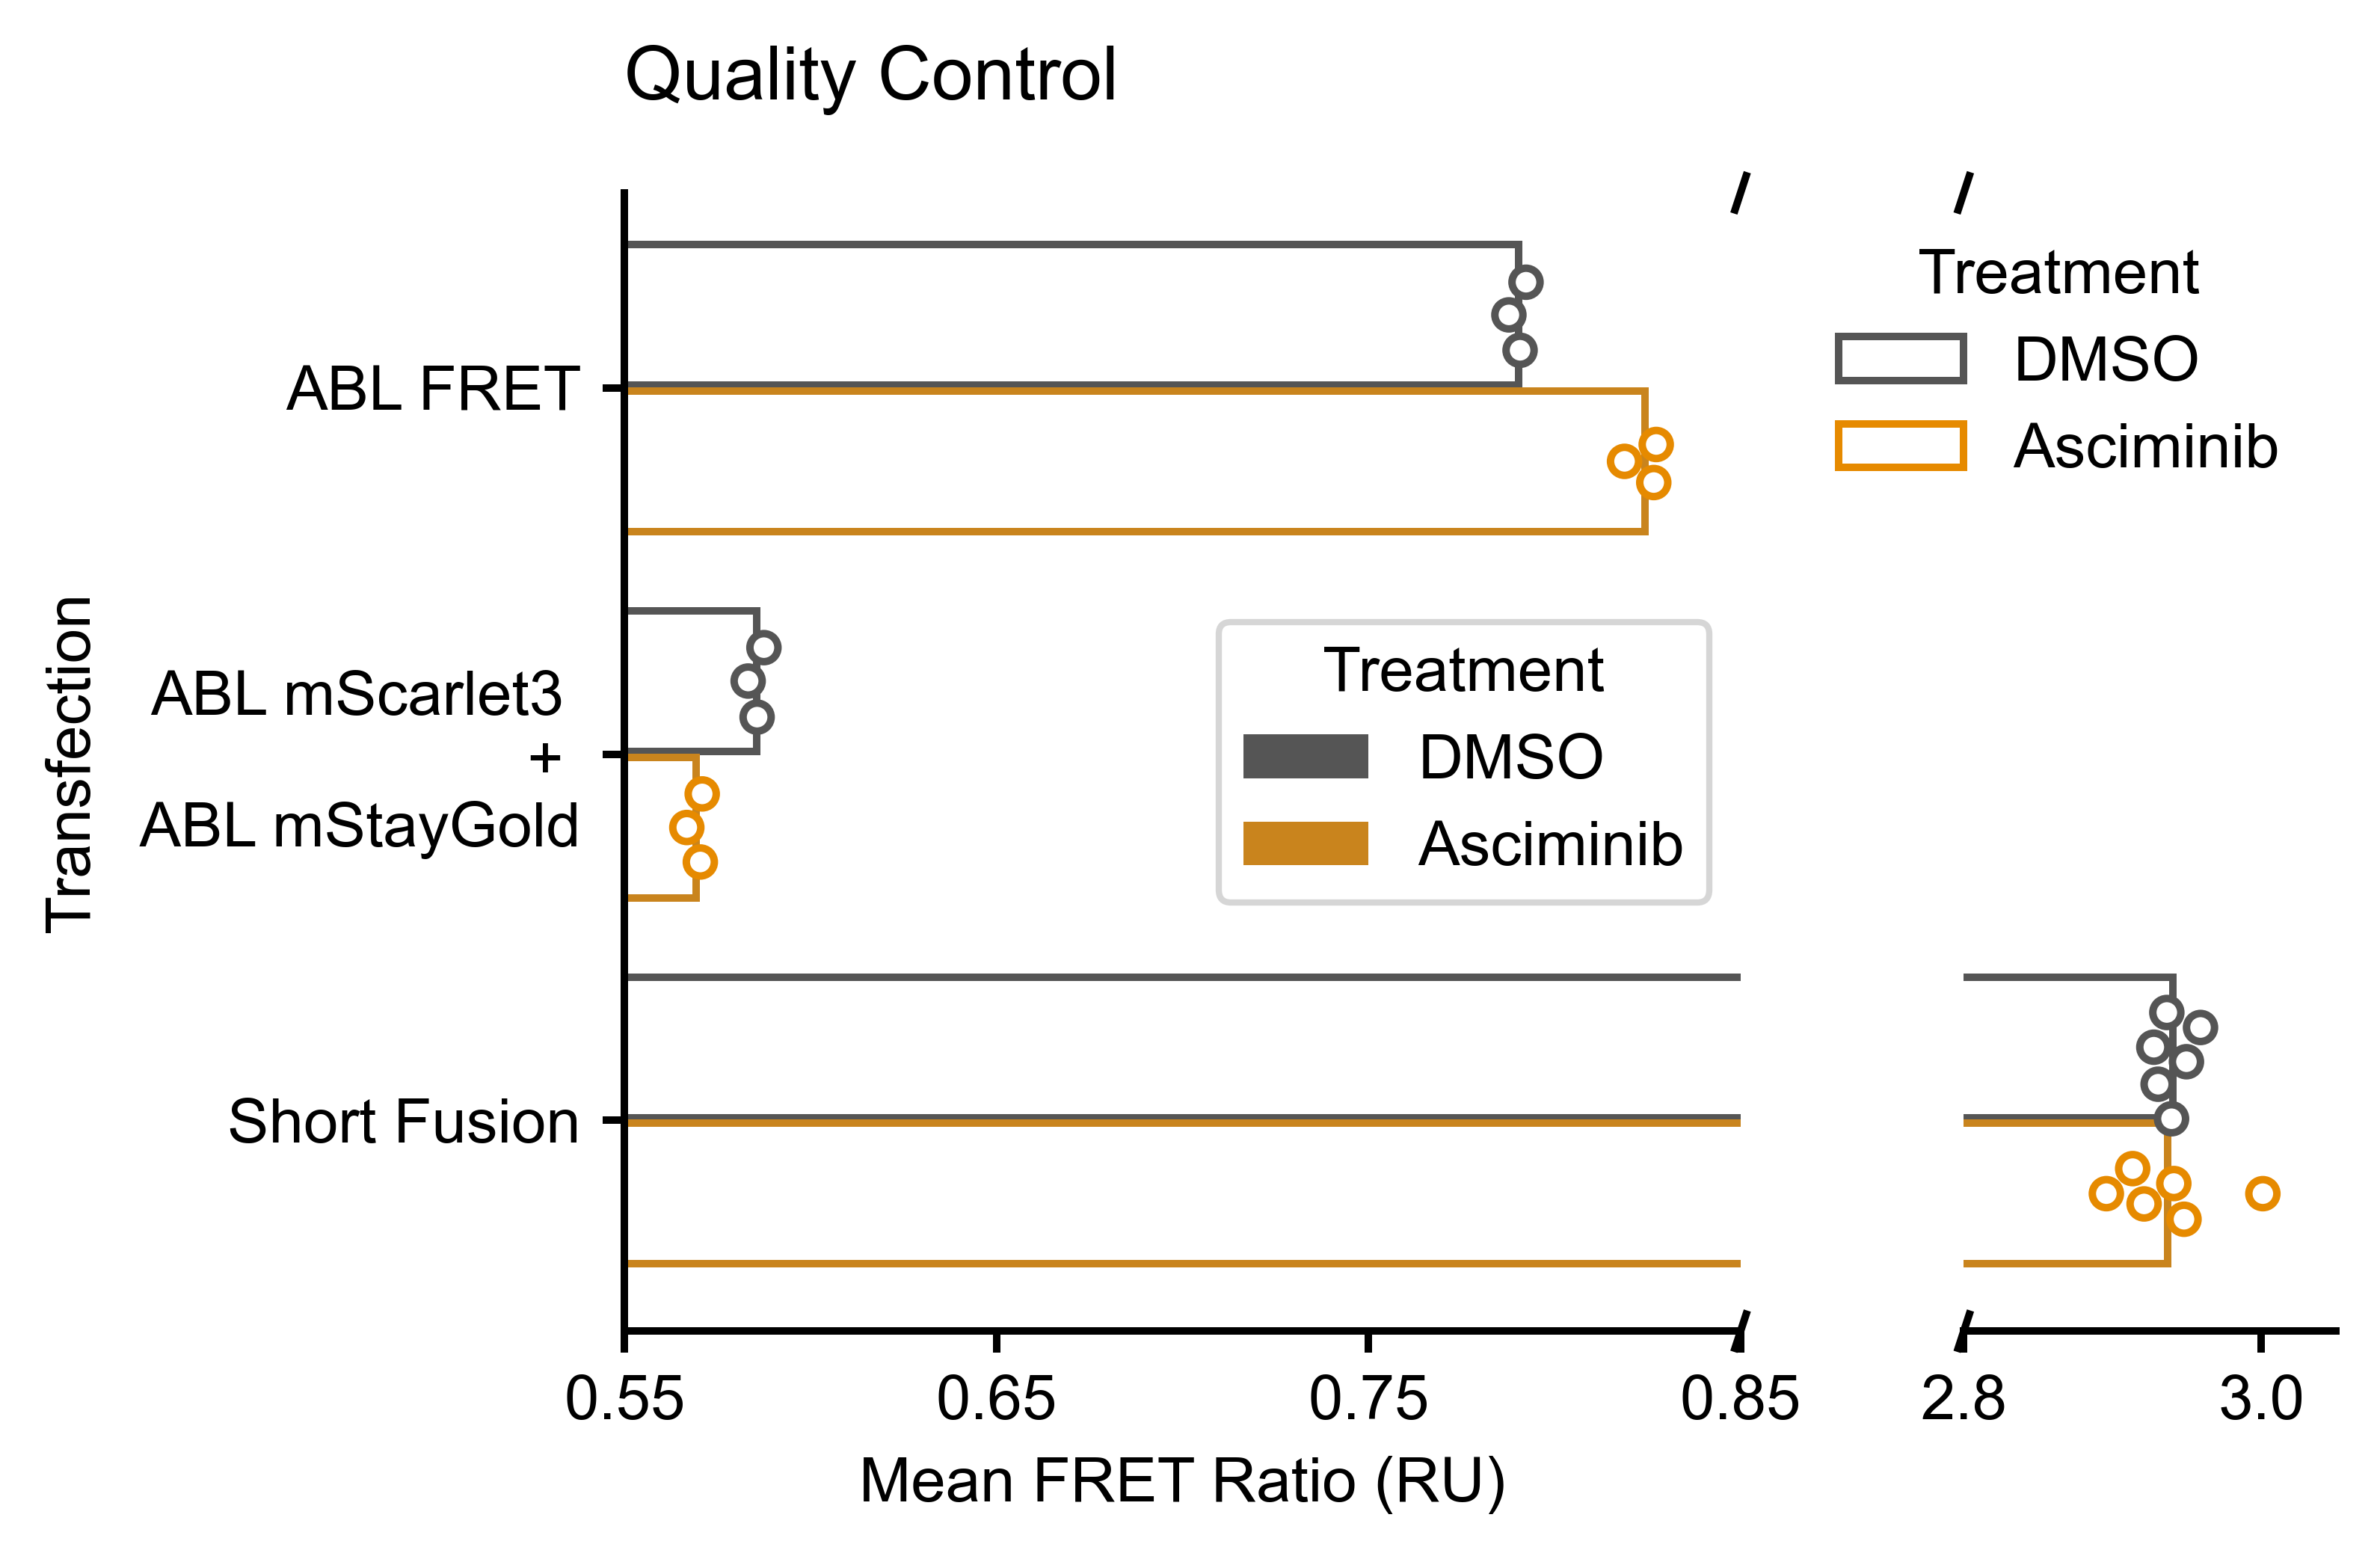

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.collections 
from matplotlib.patches import Patch
import numpy as np # Imported for diagonal lines logic

# --- 1. PUBLICATION PARAMETERS ---
LW = 1.2
# Conversion: mm to inches
width_inch = 250 / 25.4 / 2
height_inch = 167.4 / 25.4 / 2

plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.linewidth': LW,
    'xtick.major.width': LW,
    'ytick.major.width': LW,
    'pdf.fonttype': 42
})

# --- 2. DATA & SETUP ---
order = ['WT', 'ScarSG', 'PC']
hue_order = ['DMSO', 'Asciminib'] 
my_palette = ["#555555", "#E68A00"] 

# [NOTE: Ensure flowDF is loaded here before plotting]

# Initialize Figure 
# CHANGE: Increased wspace to 0.3 to prevent collision of 0.85 and 2.8
fig, (ax, ax2) = plt.subplots(1, 2, sharey=True, figsize=(width_inch, height_inch),
                                gridspec_kw={'wspace': 0.3, 'width_ratios': [3, 1]})

# --- 3. PLOTTING FUNCTION ---
def plot_subplot(target_ax):
    # Bars (Horizontal: x=FRET, y=Cell)
    sns.barplot(
        data=flowDF,
        x='FRET',           
        y='Cell',           
        hue='Treatment',
        order=order,
        hue_order=hue_order,
        palette=my_palette,
        gap=0.04,
        dodge=True,
        linewidth=LW,
        errorbar=None,     
        ax=target_ax,
        zorder=2,
        orient='h'          
    )

    # Swarm (Dots)
    sns.swarmplot(
        data=flowDF,
        x='FRET',           
        y='Cell',           
        hue='Treatment',
        order=order,
        hue_order=hue_order,
        palette=my_palette,
        dodge=True,
        size=4.5,
        ax=target_ax,
        zorder=3,
        legend=False,
        orient='h'
    )

    # Style Processing: White Fill + Colored Border
    for bar in target_ax.patches:
        clr = bar.get_facecolor()
        bar.set_edgecolor(clr)
        bar.set_facecolor("white")
        
    for collection in target_ax.collections:
        if isinstance(collection, matplotlib.collections.PathCollection):
            original_color = collection.get_facecolor()
            if len(original_color) > 0:
                collection.set_edgecolor(original_color)
                collection.set_facecolor("white")
                collection.set_linewidth(LW)

# --- 4. EXECUTE PLOTS ---
plot_subplot(ax)
plot_subplot(ax2)

# --- 5. BROKEN AXIS STYLING (HORIZONTAL) ---
ax.set_xlim(0.55, 0.85)
ax2.set_xlim(2.8, 3.05) 

ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

# ADDED: Diagonal lines to mark the break visually
d = 0.015  # Size of the diagonal lines
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, linewidth=LW)
# Draw marks on the right side of the left plot (ax)
ax.plot((1 - d/3, 1 + d/3), (-d, +d), **kwargs)      # Bottom-right diagonal
ax.plot((1 - d/3, 1 + d/3), (1 - d, 1 + d), **kwargs) # Top-right diagonal

kwargs.update(transform=ax2.transAxes) 
# Draw marks on the left side of the right plot (ax2)
ax2.plot((-d, +d), (-d, +d), **kwargs)      # Bottom-left diagonal
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs) # Top-left diagonal

# --- 6. LABELS & TICKS ---
ax.set_title('Quality Control', pad=15, loc='left') 
ax.set_xlabel('Mean FRET Ratio (RU)') 
ax2.set_xlabel('')

labels = ['ABL FRET', 'ABL mScarlet3 \n + \n ABL mStayGold', 'Short Fusion']
ax.set_yticklabels(labels)
ax.set_ylabel('Transfection')

ax.set_xticks([0.55, 0.65, 0.75, 0.85]) 
ax2.set_xticks([2.8, 3.0]) 

# --- 7. CUSTOM LEGEND ---
legend_elements = [
    Patch(facecolor='white', edgecolor=my_palette[0], linewidth=LW, label=hue_order[0]),
    Patch(facecolor='white', edgecolor=my_palette[1], linewidth=LW, label=hue_order[1])
]

ax2.legend(handles=legend_elements, 
           title='Treatment', 
           frameon=False, 
           loc='upper right', 
           bbox_to_anchor=(1.0, 1.0))

# --- 8. FINAL CLEANUP ---
sns.despine(ax=ax, right=True)
sns.despine(ax=ax2, left=True)

# CHANGE: Removed plt.tight_layout() to preserve the wspace gap
plt.savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/HEK FRET Quality Control PC Swarm2.pdf", transparent=True, dpi=600, bbox_inches='tight')
plt.show()

### One sided two sample t-test to validate BCR-ABL FRET Biosensor

In [109]:
from scipy.stats import ttest_ind
#Test if Asc increases FRET in WT vector
ttest_ind(flowDF.loc[(flowDF['Cell']=='WT') & (flowDF['Treatment']=='Asciminb'), 'FRET'], 
          flowDF.loc[(flowDF['Cell']=='WT') & (flowDF['Treatment']=='DMSO'), 'FRET'], alternative="greater")

TtestResult(statistic=11.149992313637396, pvalue=0.00018411366049005606, df=4.0)

In [110]:
#Bonferroni Correction
0.00018411366049005606 * 3

0.0005523409814701682

In [91]:
#Test if Asc increases FRET when accetor and donor are on seprate vectors
ttest_ind(flowDF.loc[(flowDF['Cell']=='ScarSG') & (flowDF['Treatment']=='Asciminb'), 'FRET'], 
          flowDF.loc[(flowDF['Cell']=='ScarSG') & (flowDF['Treatment']=='DMSO'), 'FRET'], alternative="greater")

TtestResult(statistic=-8.995275173166455, pvalue=0.999577231498686, df=4.0)

In [92]:
#Test if Asc increases FRET when accetor and donor fused together
ttest_ind(flowDF.loc[(flowDF['Cell']=='PC') & (flowDF['Treatment']=='Asciminb'), 'FRET'], 
          flowDF.loc[(flowDF['Cell']=='PC') & (flowDF['Treatment']=='DMSO'), 'FRET'], alternative="greater")

TtestResult(statistic=-0.23788376425317478, pvalue=0.5916127587961946, df=10.0)

## Spectral Overlap Between mStayGold and mScarlet3

In [45]:
spectra = pd.read_csv('fpbase_spectra.csv')
FPbase = pd.melt(spectra, id_vars='wavelength')
color_dict = {'mStayGold ex':'lime', 'mStayGold em':'lawngreen', 'mScarlet3 ex':'gold','mScarlet3 em':'red'}
dash_dict = {'mStayGold ex':'dashed', 'mStayGold em':'solid', 'mScarlet3 ex':'dashed','mScarlet3 em':'solid'}

In [46]:
FPbase['style']= FPbase['variable'].map(dash_dict)

In [47]:
FPbase

,wavelength,variable,value,style
0,351,mStayGold ex,0.0026,dashed
1,352,mStayGold ex,0.0027,dashed
2,353,mStayGold ex,0.0028,dashed
3,354,mStayGold ex,0.0029,dashed
4,355,mStayGold ex,0.0030,dashed
...,...,...,...,...
1795,796,mScarlet3 em,0.0153,solid
1796,797,mScarlet3 em,0.0153,solid
1797,798,mScarlet3 em,0.0154,solid
1798,799,mScarlet3 em,0.0148,solid


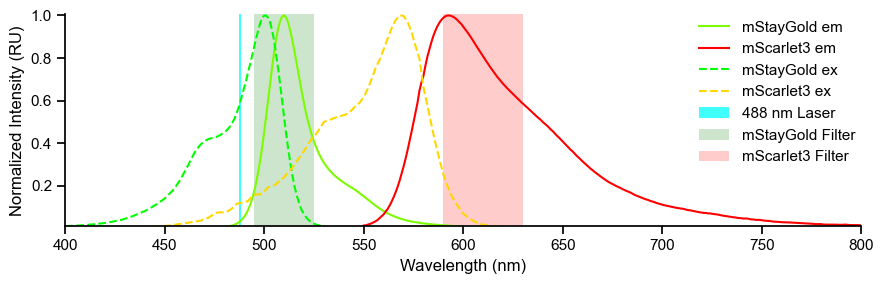

In [63]:
## Spectra
plt.rcParams['figure.figsize'] = 9,3
spec = sns.lineplot(x='wavelength', y='value', hue='variable', data=FPbase.loc[FPbase['variable'].isin(['mStayGold em', 'mScarlet3 em'])], palette=color_dict)
sns.lineplot(x='wavelength', y='value', hue='variable', linestyle='--',data=FPbase.loc[FPbase['variable'].isin(['mStayGold ex', 'mScarlet3 ex'])], palette=color_dict)
spec.set(ylabel='Normalized Intensity (RU)', xlabel='Wavelength (nm)', ylim=[0.01, 1.005], xlim=[400,800])
spec.axvspan(487.5, 488.5, color='cyan',  lw=0, alpha=0.75, label ='488 nm Laser')
spec.axvspan(495, 525, color='green', alpha=0.2, label ='mStayGold Filter', linewidth=0)
spec.axvspan(590, 630, color='red', alpha=0.2, label ='mScarlet3 Filter', linewidth=0)
spec.legend(borderaxespad=0, frameon=False)
sns.despine()
plt.tight_layout()
spec.get_figure().savefig("/home/ivan/Desktop/Epi Analysis/FRET Sensor/FRET Spectra3.pdf" , dpi=1200,  transparent=True, bbox_inches='tight')

## SHP2 FRET

In [20]:
os.chdir('/home/ivan/Desktop/Projects/FRET SHP2/20241112_213425')

In [21]:
SHP2_flow_data = []

for file in os.listdir():
    if file[-3:] == 'fcs':
        meta, data = fcsparser.parse(file, meta_data_only=False, reformat_meta=True)
        data = data.loc[(data['FSC-A'].between(3000000, 15000000)) & (data['SSC-A'] > 100000) & (data['FITC-A'].between(1000, 50000))]
        data['ScarSG_A'] = data['PerCP-A']/data['FITC-A']
        data = data.loc[data['ScarSG_A'].between(1,2)]
        SHP2_flow_data.append([file.split(' ')[2][:-4].split('_')[0], file.split(' ')[2][:-4].split('_')[1], file.split(' ')[1],  data['ScarSG_A'].mean()])
        print([file.split(' ')[2][:-4], file.split(' ')[1], len(data)])

['E76G_2', 'SHP099', 178512]
['WT_1', 'SHP099', 104671]
['E76G_1', 'NSC', 93567]
['E76G_3', 'Bato', 180449]
['E76G_1', 'SHP099', 203807]
['E76G_1', 'DMSO', 134127]
['E76G_3', 'DMSO', 129955]
['E76G_3', 'SHP099', 247767]
['WT_1', 'Bato', 115050]
['E76G_1', 'Bato', 155882]
['WT_1', 'NSC', 112512]
['WT_2', 'DMSO', 109511]
['WT_3', 'DMSO', 126606]
['E76G_2', 'DMSO', 164388]
['E76G_3', 'NSC', 165707]
['WT_1', 'DMSO', 165541]
['WT_2', 'SHP099', 128893]
['WT_2', 'Bato', 124656]
['WT_6', 'NSC', 95330]
['WT_3', 'Bato', 107326]
['WT_2', 'NSC', 129759]
['WT_3', 'SHP099', 98764]


In [22]:
SHP2_flow_data = pd.DataFrame(SHP2_flow_data, columns=['Cell', 'Rep', 'Drug', 'FRET'])
SHP2_flow_data.loc[SHP2_flow_data['Drug']=='Bato', 'Drug'] = 'Batoprotafib'

In [192]:
sns.set_context('notebook')

In [174]:
sns.set_context('paper')
plt.rcParams['font.family'] = 'Arial'
plt.rc('pdf', fonttype=42)
plt.rcParams['font.size'] = '6.5'
plt.rcParams['axes.labelsize'] = '6.5'
plt.rcParams['axes.titlesize'] = '6.5'
plt.rcParams['xtick.labelsize'] = '6.5'
plt.rcParams['ytick.labelsize'] = '6.5'
plt.rcParams['legend.fontsize'] = '6.5'
plt.rcParams['legend.title_fontsize'] = '6.5'

In [179]:
sns.reset_defaults()

In [16]:
sns.plotting_context()

{'font.size': 12.0,
 'axes.labelsize': 12.0,
 'axes.titlesize': 12.0,
 'xtick.labelsize': 11.0,
 'ytick.labelsize': 11.0,
 'legend.fontsize': 11.0,
 'legend.title_fontsize': 12.0,
 'axes.linewidth': 1.25,
 'grid.linewidth': 1.0,
 'lines.linewidth': 1.5,
 'lines.markersize': 6.0,
 'patch.linewidth': 1.0,
 'xtick.major.width': 1.25,
 'ytick.major.width': 1.25,
 'xtick.minor.width': 1.0,
 'ytick.minor.width': 1.0,
 'xtick.major.size': 6.0,
 'ytick.major.size': 6.0,
 'xtick.minor.size': 4.0,
 'ytick.minor.size': 4.0}

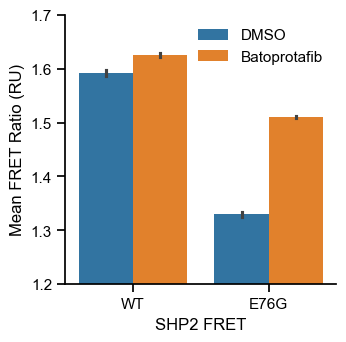

In [25]:
plt.rcParams['figure.figsize'] = 3.5,3.5
bar = sns.barplot(x='Cell', y='FRET', hue='Drug',errorbar='sd', hue_order = ['DMSO','Batoprotafib'], order=['WT', 'E76G'], data=SHP2_flow_data)
bar.set(ylabel='Mean FRET Ratio (RU)', xlabel='SHP2 FRET', ylim=[1.2, 1.7])
bar.legend(frameon=False)
sns.despine()
bar.get_figure().savefig('/home/ivan/Desktop/Epi Analysis/FRET Sensor/SHP2 FRET 1uM Drug2.pdf', bbox_inches='tight', dpi=1200,  transparent=True)

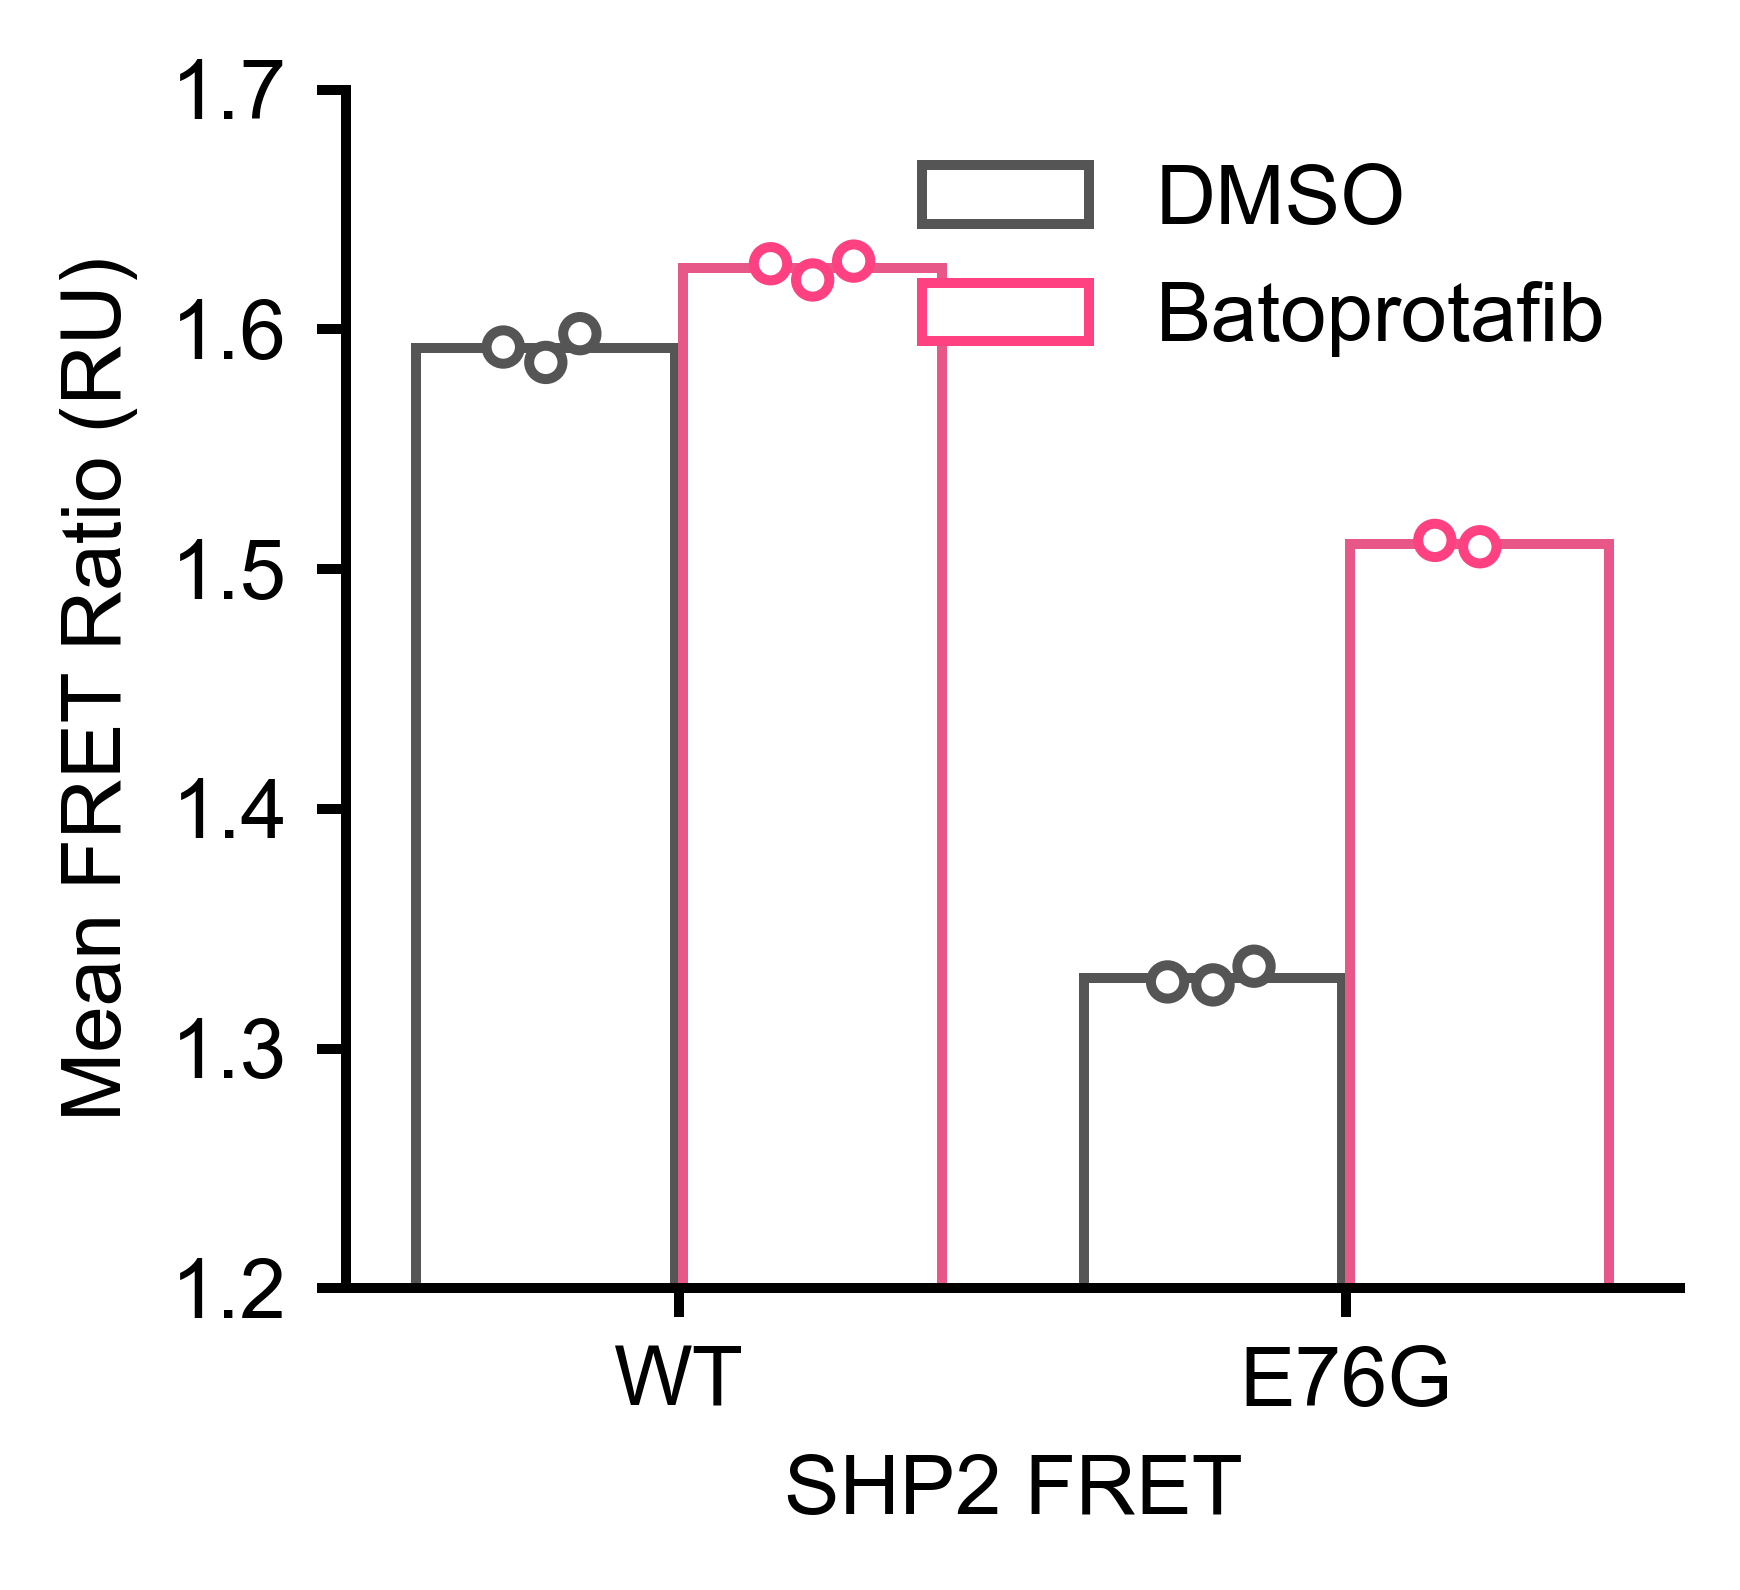

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.collections 

# --- 1. PUBLICATION PARAMETERS ---
LW = 1.2
# Using your requested 3.5 inch dimensions
width_inch = 3
height_inch = 2.75

plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.linewidth': LW,
    'xtick.major.width': LW,
    'ytick.major.width': LW,
    'pdf.fonttype': 42
})

# --- 2. DATA & SETUP ---
# Defining specific order and palette to match previous style
order = ['WT', 'E76G']
hue_order = ['DMSO', 'Batoprotafib']
my_palette = ["#555555", "#FF4081"] # Gray for Control, Orange for Drug

fig, ax = plt.subplots(figsize=(width_inch, height_inch))

# --- 3. PLOTTING ---
# Bar Plot (Vertical)
sns.barplot(
    data=SHP2_flow_data,
    x='Cell',
    y='FRET',
    hue='Drug',
    order=order,
    hue_order=hue_order,
    palette=my_palette,
    linewidth=LW,
    capsize=0.01,    # Adds caps to error bars for cleaner look
    err_kws={'linewidth': LW},
    errorbar=None,  # Kept your requested Standard Deviation
    gap=0.03,
    ax=ax,
    zorder=2
)

# Swarm Plot (Dots) - Added to match the previous "Swarm" style
sns.swarmplot(
    data=SHP2_flow_data,
    x='Cell',
    y='FRET',
    hue='Drug',
    order=order,
    hue_order=hue_order,
    palette=my_palette,
    dodge=True,
    size=4,
    ax=ax,
    zorder=3,
    legend=False
)

# --- 4. STYLE PROCESSING (Hollow Bars) ---
# White Fill + Colored Border for Bars
for bar in ax.patches:
    clr = bar.get_facecolor()
    bar.set_edgecolor(clr)
    bar.set_facecolor("white")

# White Fill + Colored Border for Swarm Dots
for collection in ax.collections:
    if isinstance(collection, matplotlib.collections.PathCollection):
        original_color = collection.get_facecolor()
        if len(original_color) > 0:
            collection.set_edgecolor(original_color)
            collection.set_facecolor("white")
            collection.set_linewidth(LW)

# --- 5. LABELS & AXIS ---
ax.set_ylabel('Mean FRET Ratio (RU)')
ax.set_xlabel('SHP2 FRET')
ax.set_ylim([1.2, 1.7])

# --- 6. CUSTOM LEGEND ---
# Manually create legend handles to match the hollow bar style
legend_elements = [
    Patch(facecolor='white', edgecolor=my_palette[0], linewidth=LW, label=hue_order[0]),
    Patch(facecolor='white', edgecolor=my_palette[1], linewidth=LW, label=hue_order[1])
]

ax.legend(handles=legend_elements, 
          frameon=False, 
          loc='upper right')

# --- 7. FINAL CLEANUP ---
sns.despine()
plt.tight_layout()
plt.savefig('/home/ivan/Desktop/Epi Analysis/FRET Sensor/SHP2 FRET 1uM Drug 260119.pdf', 
            bbox_inches='tight', dpi=1200, transparent=True)
plt.show()

In [142]:
#Test if Asc increases FRET when accetor and donor fused together
test1 = ttest_ind(SHP2_flow_data.loc[(SHP2_flow_data['Cell']=='WT') & (SHP2_flow_data['Drug']=='Batoprotafib'), 'FRET'], 
          SHP2_flow_data.loc[(SHP2_flow_data['Cell']=='WT') & (SHP2_flow_data['Drug']=='DMSO'), 'FRET'], alternative="greater")
test1.pvalue*3

0.0021871762543309568

In [144]:
test2 = ttest_ind(SHP2_flow_data.loc[(SHP2_flow_data['Cell']=='E76G') & (SHP2_flow_data['Drug']=='Batoprotafib'), 'FRET'], 
          SHP2_flow_data.loc[(SHP2_flow_data['Cell']=='E76G') & (SHP2_flow_data['Drug']=='DMSO'), 'FRET'], alternative="greater")
test2.pvalue*3

1.9540998387810656e-05

In [145]:
test3 = ttest_ind(SHP2_flow_data.loc[(SHP2_flow_data['Cell']=='E76G') & (SHP2_flow_data['Drug']=='DMSO'), 'FRET'], 
          SHP2_flow_data.loc[(SHP2_flow_data['Cell']=='WT') & (SHP2_flow_data['Drug']=='DMSO'), 'FRET'], alternative="less")
test3.pvalue*3

6.002747561857377e-07